<a href="https://colab.research.google.com/github/KonstatinB/Agentic-Use/blob/main/Practical_Business_Use_Cases_for_Agentic_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#080228 0%,#58250E 48%,#B82D21 100%);padding:40px 36px;border-radius:16px;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:26px">
    <div style="background:#F58D06;color:#080228;font-weight:800;font-size:22px;letter-spacing:-1.5px;padding:7px 15px;border-radius:9px;line-height:1">at</div>
    <div style="font-size:12px;letter-spacing:3.5px;text-transform:uppercase;opacity:.88;font-weight:600">Africa&#39;s Talking &nbsp;&#183;&nbsp; AI/ML Community</div>
    <div style="margin-left:auto;font-size:12px;opacity:.65;letter-spacing:1px">#WeLoveNerds</div>
  </div>
  <h1 style="margin:0;font-size:46px;line-height:1.03;font-weight:800;letter-spacing:-1px">Agentic AI in<br>the Real World</h1>
  <p style="margin:16px 0 0;font-size:20px;color:#F3A72A;font-weight:600;line-height:1.35">Practical Business Use Cases for Agentic AI<br>with the OpenAI Agents SDK</p>
  <div style="height:3px;width:90px;background:#F58D06;margin:26px 0 22px;border-radius:2px"></div>
  <table style="color:#F8FAFD;font-size:14px;border-collapse:collapse;background:transparent">
    <tr><td style="padding:3px 22px 3px 0;opacity:.6;border:none">Speaker</td><td style="padding:3px 0;border:none;font-weight:600">Ronnie Ochieng &#183; Software Developer, Davis &amp; Shirtliff</td></tr>
    <tr><td style="padding:3px 22px 3px 0;opacity:.6;border:none">Session</td><td style="padding:3px 0;border:none;font-weight:600">Sizing Tools with the OpenAI Agents SDK</td></tr>
    <tr><td style="padding:3px 22px 3px 0;opacity:.6;border:none">When</td><td style="padding:3px 0;border:none;font-weight:600">16 September &#183; 18:00&#8211;20:00 EAT</td></tr>
    <tr><td style="padding:3px 22px 3px 0;opacity:.6;border:none">Register</td><td style="padding:3px 0;border:none;font-weight:600"><a href="https://community.africastalking.com/e/mvn22x/" style="color:#F3A72A">community.africastalking.com/e/mvn22x</a></td></tr>
  </table>
</div>

## About this notebook

This is the companion workbook for the session. It is written to be **read end-to-end after the
talk** as well as **run cell-by-cell during it**. Everything is self-contained.

### What you will walk away with

1. A precise definition of "agentic AI" and an honest account of when *not* to use it.
2. A working map of the framework landscape: **OpenAI Agents SDK, LangGraph, CrewAI, AutoGen, Semantic Kernel, smolagents, LlamaIndex Workflows, Pydantic AI, Strands**.
3. A deep, hands-on tour of every OpenAI Agents SDK primitive: `Agent`, `function_tool`, the run
   loop, handoffs, guardrails, sessions, context, structured outputs, hooks and **tracing**.
4. A production case study: the **AI Sizing Engine** at Davis &amp; Shirtliff, which took
   water-treatment proposal turnaround from **5.4 days to about 10 minutes**.
5. A mini sizing agent you build yourself in Part 5.

### Two run modes

| Mode | Requirement | What runs |
| --- | --- | --- |
| **LIVE** | An `OPENAI_API_KEY` | Every cell, including real model calls |
| **OFFLINE** | Nothing | Concepts, schema introspection, the full tracing demo and all charts |

The tracing deep dive (Part 3.9) and every diagram work **without an API key**, because they are the
parts you most need to study slowly.

### Agenda

| Part | Topic | Time |
| --- | --- | --- |
| 0 | Demo first: the sizing engine in action | 10 min |
| 1 | What agentic AI actually is | 15 min |
| 2 | The framework landscape and how to choose | 15 min |
| 3 | OpenAI Agents SDK, demystified | 45 min |
| 4 | Case study: 5.4 days to 10 minutes | 25 min |
| 5 | Build your own sizing agent | 10 min |

<div style="background:#080228;padding:22px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 0</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">Demo first, theory second</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">A lab report goes in. A costed, WHO-compliant, ERP-priced proposal comes out.</div>
</div>

Before a single definition, watch the thing work. Keep one question in your head:

> **Which of these steps is the language model actually doing, and which are plain deterministic code?**

By the end of Part 4 you should be able to answer that for every second of the video. The answer is
the whole lesson of this session.

In [ ]:
from IPython.display import HTML, display

# The sizing engine in action (Davis & Shirtliff AI Product Sizing).
# Replace DEMO_VIDEO_ID if you re-upload the recording.
DEMO_VIDEO_ID = "1223739717"
DEMO_VIDEO_URL = "https://vimeo.com/" + DEMO_VIDEO_ID

display(HTML(
    """
    <div style="position:relative;padding-bottom:56.25%;height:0;border-radius:12px;overflow:hidden;
                box-shadow:0 10px 34px rgba(8,2,40,.28)">
      <iframe src="https://player.vimeo.com/video/{vid}?title=0&byline=0&portrait=0"
              style="position:absolute;top:0;left:0;width:100%;height:100%;border:0"
              allow="autoplay; fullscreen; picture-in-picture" allowfullscreen></iframe>
    </div>
    <p style="font-family:Inter,'Segoe UI',sans-serif;font-size:13px;color:#393939;margin-top:12px">
      If the embed is blocked by your browser, open it directly:
      <a href="{url}" style="color:#D7760C;font-weight:600">{url}</a>
    </p>
    """.format(vid=DEMO_VIDEO_ID, url=DEMO_VIDEO_URL)
))

### What you just watched, in agentic terms

| On screen | Underneath |
| --- | --- |
| A lab report PDF is dropped in | Multimodal extraction: page images to a vision model, plus a deterministic table reconstructor that argues with it |
| Parameters appear, flagged PASS/FAIL | Rule evaluation against WHO / KEBS guideline presets |
| "Reverse Osmosis" is chosen, not filtration | A **deterministic decision tree**, not the model, picks the primary process |
| Equipment, sizes and quantities fill in | Specialist agents calling typed Python sizing tools |
| Prices land per line item | Live lookups against Microsoft Dynamics 365 Business Central by `bc_item_no` |
| A readable proposal narrative is written | *This* is where the LLM genuinely shines |
| A step-by-step "how the AI decided" panel | Every SDK span persisted to Postgres by a custom `TracingProcessor` |

**The headline:** a proposal that historically took a sales engineer **5.4 days** now takes about
**10 minutes**. Part 4 breaks down exactly how, and quantifies it.

---
## Setup

Three cells: install, brand and plotting theme, credentials. Run them in order.

In [ ]:
# Colab-friendly install. Takes ~30-45s on a cold runtime.
%pip install -q "openai-agents>=0.6" "openai>=2.0" "pydantic>=2.7" matplotlib pandas

import agents
print("openai-agents version:", agents.version.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.0 MB/s eta 0:00:00
openai-agents version: 0.22.2


In [ ]:
# ---------------------------------------------------------------------------
# Africa's Talking brand tokens.
# Hex values sampled directly from africastalking.com and the session poster,
# so charts in this notebook match the deck.
# ---------------------------------------------------------------------------
BRAND = {
    "orange":      "#F58D06",   # primary
    "orange_deep": "#D7760C",
    "amber":       "#F3A72A",
    "ink":         "#080228",   # near-black indigo (AT site header)
    "maroon":      "#B82D21",   # session poster gradient
    "brown":       "#58250E",
    "paper":       "#F8FAFD",
    "slate":       "#393939",
    "mist":        "#E7E8EB",
}
SEQ = [BRAND["orange"], BRAND["ink"], BRAND["maroon"], BRAND["amber"],
       BRAND["orange_deep"], BRAND["slate"], BRAND["brown"]]

import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler

mpl.rcParams.update({
    "figure.facecolor":  BRAND["paper"],
    "axes.facecolor":    BRAND["paper"],
    "axes.edgecolor":    BRAND["mist"],
    "axes.labelcolor":   BRAND["ink"],
    "axes.titlecolor":   BRAND["ink"],
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.grid":         True,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "grid.color":        BRAND["mist"],
    "grid.linewidth":    0.8,
    "text.color":        BRAND["ink"],
    "xtick.color":       BRAND["slate"],
    "ytick.color":       BRAND["slate"],
    "font.size":         11,
    "figure.dpi":        110,
    "axes.prop_cycle":   cycler(color=SEQ),
})

print("Brand tokens loaded:", ", ".join(BRAND))

Brand tokens loaded: orange, orange_deep, amber, ink, maroon, brown, paper, slate, mist


In [ ]:
import os, getpass

# 1) Colab secret (left sidebar -> key icon -> add OPENAI_API_KEY, enable notebook access)
try:
    from google.colab import userdata
    _k = userdata.get("OPENAI_API_KEY")
    if _k:
        os.environ["OPENAI_API_KEY"] = _k
except Exception:
    pass

# 2) Fall back to a prompt. Press Enter to stay OFFLINE.
if not os.environ.get("OPENAI_API_KEY"):
    _k = getpass.getpass("OPENAI_API_KEY (press Enter for OFFLINE mode): ").strip()
    if _k:
        os.environ["OPENAI_API_KEY"] = _k

LIVE = bool(os.environ.get("OPENAI_API_KEY"))

# Small, cheap model for the workshop. Change if your org has different access.
DEMO_MODEL = "gpt-4.1-mini"


async def arun(agent, prompt, **kwargs):
    """Run an agent, or explain the intent when no key is configured.

    Notebooks already have a running event loop, so use `await arun(...)`
    rather than `Runner.run_sync(...)`, which cannot nest inside one.
    """
    from agents import Runner
    if not LIVE:
        print("[OFFLINE] Would run agent '{}' with prompt:\n  {}".format(
            getattr(agent, "name", "?"), prompt[:220].replace("\n", " ")))
        return None
    return await Runner.run(agent, prompt, **kwargs)


print("Mode:", "LIVE (model calls enabled)" if LIVE else "OFFLINE (concepts, schemas, tracing, charts)")

Mode: LIVE (model calls enabled)


---
<div style="background:#080228;padding:22px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 1</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">What agentic AI actually is</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">Stripping the term down to something you can engineer against.</div>
</div>

### 1.1 One sentence, then the nuance

> An **agent** is an LLM that has been given tools and a goal, and is allowed to decide, in a loop,
> which tools to call and when it is finished.

That is it. The novelty is not the model; it is **who owns the control flow**. In classic software,
you write the `if` statements. In an agentic system, the model writes them at runtime.

That single shift is what buys you flexibility, and it is also the entire source of your new
problems: non-determinism, cost variance, silent failure, and the need for observability.

### 1.2 The autonomy ladder

Most production "AI features" sit far lower on this ladder than the marketing suggests, and that is
usually the correct engineering decision.

| Level | Pattern | Who decides the next step | Typical use |
| --- | --- | --- | --- |
| **L0** | Single prompt | You | Summarise, classify, rewrite |
| **L1** | Chain / pipeline | You, in code | Extract, then validate, then format |
| **L2** | Router | Model picks one branch | Triage a support ticket |
| **L3** | Tool-using agent | Model loops over tools | Look up, compute, answer |
| **L4** | Multi-agent with handoffs | Model delegates to specialists | The sizing engine |
| **L5** | Open-ended autonomy | Model sets its own goals | Mostly research, rarely production |

The Davis &amp; Shirtliff sizing engine is deliberately **L4 for coordination and L1 for engineering
maths**. Read that twice; it is the reason it survived contact with real customers.

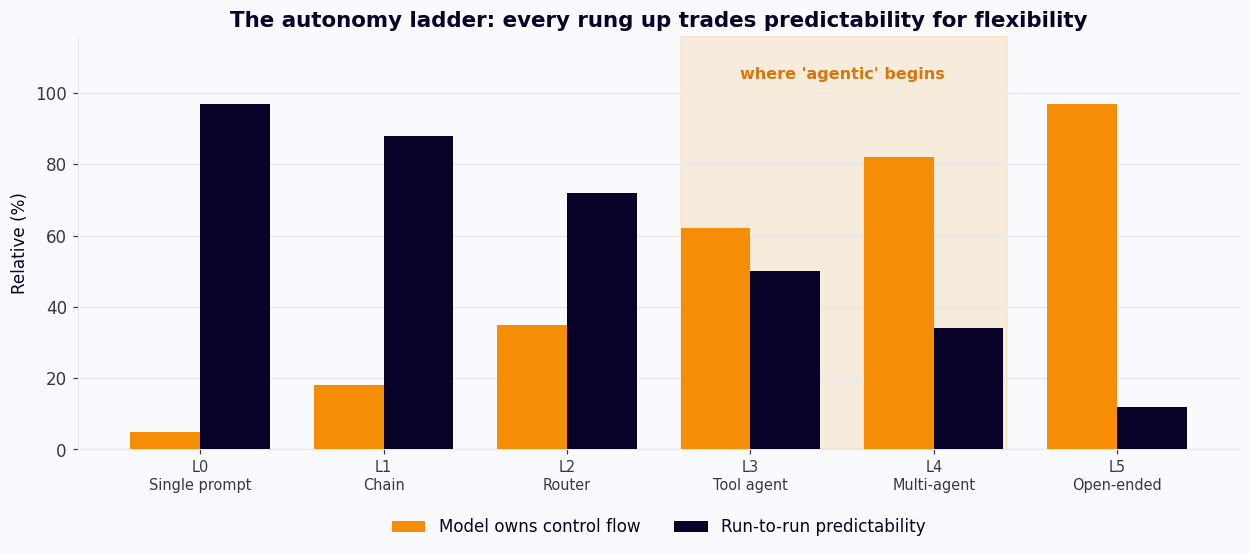

Sizing engine: L4 for coordination, L1 for engineering calculations.


In [ ]:
import numpy as np

levels = ["L0\nSingle prompt", "L1\nChain", "L2\nRouter", "L3\nTool agent",
          "L4\nMulti-agent", "L5\nOpen-ended"]
autonomy      = [5, 18, 35, 62, 82, 97]   # how much control flow the model owns
predictability = [97, 88, 72, 50, 34, 12]  # how confidently you can predict a run

x = np.arange(len(levels))
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.bar(x - 0.19, autonomy, width=0.38, label="Model owns control flow",
       color=BRAND["orange"], zorder=3)
ax.bar(x + 0.19, predictability, width=0.38, label="Run-to-run predictability",
       color=BRAND["ink"], zorder=3)

ax.axvspan(2.62, 4.4, color=BRAND["amber"], alpha=0.16, zorder=0)
ax.text(3.5, 104, "where 'agentic' begins", ha="center", fontsize=10.5,
        fontweight="bold", color=BRAND["orange_deep"])

ax.set_xticks(x); ax.set_xticklabels(levels, fontsize=9.5)
ax.set_ylabel("Relative (%)"); ax.set_ylim(0, 116)
ax.set_title("The autonomy ladder: every rung up trades predictability for flexibility")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Sizing engine: L4 for coordination, L1 for engineering calculations.")

### 1.3 The agent loop, with no framework at all

Every agent framework is a wrapper around the same seven steps. Write them once by hand and the
frameworks stop being magic.

```
1. Describe your tools as JSON schemas
2. Send: system prompt + conversation + tool schemas
3. Model replies with either final text, or one/many tool calls
4. If final text -> stop
5. Otherwise: parse arguments, dispatch to real Python, catch errors
6. Append tool results to the conversation
7. Go to 2, unless a turn limit is hit
```

The cell below implements exactly that against the raw OpenAI API. It is the honest baseline you
should compare every framework to.

In [ ]:
import json

# ---- Two "engineering" tools, deliberately boring and deterministic -------
def ro_feed_flow(permeate_m3_h: float, recovery: float = 0.5) -> dict:
    feed = permeate_m3_h / recovery
    return {"feed_m3_h": round(feed, 2), "reject_m3_h": round(feed - permeate_m3_h, 2)}

def who_check(parameter: str, value: float) -> dict:
    limits = {"tds": 1000.0, "fluoride": 1.5, "nitrate": 50.0, "iron": 0.3, "turbidity": 5.0}
    limit = limits.get(parameter.lower())
    if limit is None:
        return {"parameter": parameter, "verdict": "NO_GUIDELINE"}
    return {"parameter": parameter, "value": value, "who_limit": limit,
            "verdict": "PASS" if value <= limit else "FAIL"}

REGISTRY = {"ro_feed_flow": ro_feed_flow, "who_check": who_check}

# ---- Hand-written JSON schemas: the part you will never miss -------------
SCHEMAS = [
    {"type": "function", "function": {
        "name": "ro_feed_flow",
        "description": "Compute RO feed and reject flow from permeate flow and recovery.",
        "parameters": {"type": "object", "properties": {
            "permeate_m3_h": {"type": "number", "description": "Permeate flow in m3/h"},
            "recovery": {"type": "number", "description": "Recovery fraction 0-1"}},
            "required": ["permeate_m3_h"]}}},
    {"type": "function", "function": {
        "name": "who_check",
        "description": "Compare one water quality parameter against the WHO guideline.",
        "parameters": {"type": "object", "properties": {
            "parameter": {"type": "string"}, "value": {"type": "number"}},
            "required": ["parameter", "value"]}}},
]

def raw_agent_loop(user_message: str, max_turns: int = 6, verbose: bool = True):
    """The whole agentic pattern, no framework, ~35 lines."""
    from openai import OpenAI
    client = OpenAI()
    messages = [
        {"role": "system", "content": "You are a water treatment sizing assistant. "
                                      "Always use tools for numbers. Never guess."},
        {"role": "user", "content": user_message},
    ]
    for turn in range(1, max_turns + 1):
        resp = client.chat.completions.create(
            model=DEMO_MODEL, messages=messages, tools=SCHEMAS)
        msg = resp.choices[0].message
        messages.append(msg.model_dump(exclude_none=True))

        if not msg.tool_calls:                                  # step 4
            if verbose:
                print("turn {}: FINAL".format(turn))
            return msg.content

        for call in msg.tool_calls:                             # step 5
            fn = REGISTRY.get(call.function.name)
            try:
                args = json.loads(call.function.arguments or "{}")
                result = fn(**args) if fn else {"error": "unknown tool"}
            except Exception as exc:                            # a real loop must not die here
                result = {"error": "{}: {}".format(type(exc).__name__, exc)}
            if verbose:
                print("turn {}: tool {}({}) -> {}".format(
                    turn, call.function.name, args, result))
            messages.append({"role": "tool", "tool_call_id": call.id,   # step 6
                             "content": json.dumps(result)})
    raise RuntimeError("max turns exceeded")                    # step 7


QUESTION = ("Our borehole is 1,840 mg/L TDS and 2.4 mg/L fluoride. "
            "We need 6 m3/h of treated water. Check compliance and tell me the RO feed flow.")

if LIVE:
    print(raw_agent_loop(QUESTION))
else:
    print("[OFFLINE] The tools themselves are pure Python, so run them directly:")
    print("  who_check('tds', 1840)   ->", who_check("tds", 1840))
    print("  who_check('fluoride', 2.4) ->", who_check("fluoride", 2.4))
    print("  ro_feed_flow(6.0)        ->", ro_feed_flow(6.0))

turn 1: tool who_check({'parameter': 'TDS', 'value': 1840}) -> {'parameter': 'TDS', 'value': 1840, 'who_limit': 1000.0, 'verdict': 'FAIL'}
turn 1: tool who_check({'parameter': 'fluoride', 'value': 2.4}) -> {'parameter': 'fluoride', 'value': 2.4, 'who_limit': 1.5, 'verdict': 'FAIL'}
turn 2: tool ro_feed_flow({'permeate_m3_h': 6}) -> {'feed_m3_h': 12.0, 'reject_m3_h': 6.0}
turn 3: FINAL
The borehole water does not comply with WHO guidelines for both TDS and fluoride, as the TDS is 1840 mg/L (limit 1000 mg/L) and fluoride is 2.4 mg/L (limit 1.5 mg/L).

To produce 6 m3/h of treated water using RO, the required feed flow is 12 m3/h assuming a typical recovery of 50%.


That loop works. Now count what it is **missing** before you would put it in front of a paying
customer:

- retries, timeouts and backoff on model and tool failures
- streaming, so a 40-second run is not a blank screen
- structured, validated output instead of free text
- conversation persistence across requests
- input/output validation to stop prompt injection and off-topic abuse
- delegation to specialists, each with its own prompt and tool set
- **observability**: which tool ran, with what arguments, for how long, costing how many tokens

Every one of those is a framework feature. That list *is* the reason frameworks exist, and it is the
scorecard for Part 2.

### 1.4 When not to build an agent

Four honest rules, learned the hard way:

1. **If the control flow is known, write the control flow.** A model that "decides" to run steps
   1-2-3 in order is a liability, not a feature.
2. **Never let a model do arithmetic that a spec sheet can answer.** Membrane counts, pump duty
   points and pipe friction losses are code, not vibes.
3. **If you cannot audit it, you cannot sell it.** In regulated or high-value sales, "the AI said so"
   is not an acceptable justification. Tracing is not a nice-to-have.
4. **Latency and cost are user-facing.** Each agent turn is a round trip. Five specialists chatting
   freely is a slow, expensive way to reach a wrong answer.

---
<div style="background:#080228;padding:22px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 2</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">The framework landscape</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">Nine credible options, and a defensible way to choose between them.</div>
</div>

### 2.1 The contenders

| Framework | Core abstraction | Sweet spot | Main cost |
| --- | --- | --- | --- |
| **OpenAI Agents SDK** (`openai-agents`) | Agent + tools + handoffs | Tool-heavy multi-specialist apps that need first-class tracing | Less explicit about long-running, resumable state |
| **LangGraph** | Stateful graph of nodes and edges | Durable, resumable, human-in-the-loop workflows with cycles | Highest concept load; you model a state machine |
| **CrewAI** | Crew of roles running tasks | Fast prototypes of role-play style teams | Opinionated; harder to bend to odd control flow |
| **AutoGen / AG2** | Conversing agents, group chat | Research, code execution, emergent collaboration | Conversation-as-architecture is hard to constrain |
| **Semantic Kernel** | Kernel + plugins + planners | .NET and enterprise Microsoft estates | Heavier ceremony for small Python services |
| **smolagents** (HF) | Agents that write Python | Compact, code-first agents | Executing generated code needs sandboxing |
| **LlamaIndex Workflows** | Event-driven steps | RAG-centric pipelines with agentic steps | Retrieval-first worldview |
| **Pydantic AI** | Typed agents and validated IO | Teams that want type safety above all | Younger ecosystem |
| **Strands Agents** (AWS) | Model-driven loop | AWS-native deployments | Tied to the AWS story |

Two things worth saying out loud, because vendor content rarely does:

- **These overlap heavily.** Agents, tools, memory, handoffs. The differences are ergonomics,
  observability and how state is handled, not raw capability.
- **You can mix them.** The sizing engine has both `openai-agents` and `langgraph`. The Agents SDK runs the agent layer; graph-shaped deterministic pipelines
  live elsewhere. Frameworks are not religions.

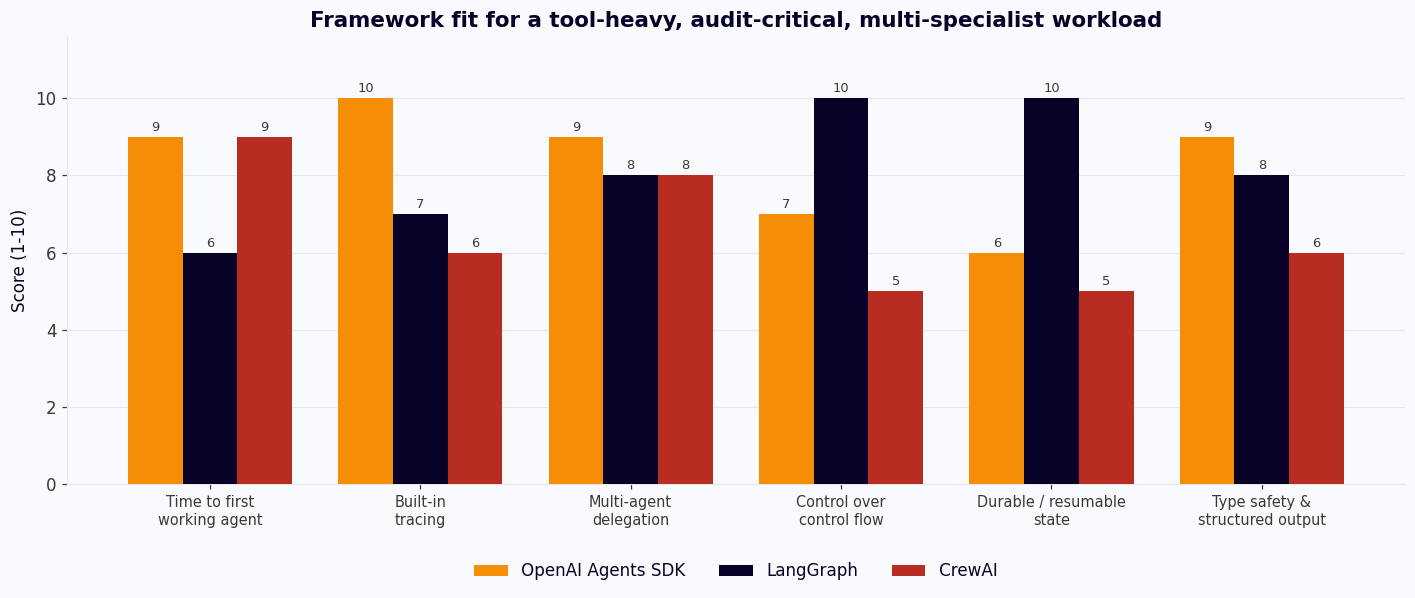

These are our subjective scores for THIS workload, as of the SDK versions in requirements.txt.
Score your own workload; the ranking changes with the problem.


In [ ]:
import pandas as pd

criteria = ["Time to first\nworking agent", "Built-in\ntracing", "Multi-agent\ndelegation",
            "Control over\ncontrol flow", "Durable / resumable\nstate", "Type safety &\nstructured output"]
scores = {
    "OpenAI Agents SDK": [9, 10, 9, 7, 6, 9],
    "LangGraph":         [6,  7, 8, 10, 10, 8],
    "CrewAI":            [9,  6, 8,  5,  5, 6],
}

x = np.arange(len(criteria)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 5.6))
for i, (name, vals) in enumerate(scores.items()):
    bars = ax.bar(x + (i - 1) * w, vals, width=w, label=name, color=SEQ[i], zorder=3)
    ax.bar_label(bars, fontsize=8.5, padding=2, color=BRAND["slate"])

ax.set_xticks(x); ax.set_xticklabels(criteria, fontsize=9.5)
ax.set_ylim(0, 11.6); ax.set_ylabel("Score (1-10)")
ax.set_title("Framework fit for a tool-heavy, audit-critical, multi-specialist workload")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("These are our subjective scores for THIS workload, as of the SDK versions in requirements.txt.")
print("Score your own workload; the ranking changes with the problem.")

### 2.2 A decision guide that actually discriminates

Ask these five questions in order. The first "yes" usually settles it.

1. **Does a run need to pause for hours and resume exactly where it stopped** (human approval,
   overnight batch, long-running job)? &rarr; **LangGraph**, for checkpointing and durable state.
2. **Is the hard part choosing and calling many typed tools, and proving afterwards what happened?**
   &rarr; **OpenAI Agents SDK**.
3. **Are you prototyping a team-of-roles narrative to show stakeholders this week?** &rarr; **CrewAI**.
4. **Is your production runtime .NET, or your cloud contract AWS-first?** &rarr; **Semantic Kernel**
   or **Strands**.
5. **Is the whole product retrieval over your documents?** &rarr; **LlamaIndex Workflows**.

### 2.3 Why the sizing engine chose the Agents SDK

Seven reasons, each traceable to a real file in the codebase rather than a slogan.

1. **The engineering code already existed as plain Python.** Hydraulics, decision trees and BOQ
   resolution were battle-tested functions. `@function_tool` exposed them to a model in one line,
   with zero rewriting. A graph framework would have meant re-expressing working code as nodes.
2. **Handoffs modelled the real organisation chart.** Davis &amp; Shirtliff has a pump desk, a
   treatment desk, a solar desk and a commercial desk. The SDK let that map one-to-one onto
   `Pump Sizing Specialist`, `Water Treatment Specialist`, `Solar System Designer` and
   `Commercial Intelligence`.
3. **Tracing is a first-class, *pluggable* primitive.** Not a vendor dashboard you rent: a
   `TracingProcessor` interface we implemented against our own Postgres. See Part 3.9 and 4.7.
4. **`group_id` gave us free correlation.** Setting `group_id = workflow_id` means every span
   already joins to the business record it belongs to. No correlation IDs to invent.
5. **Provider-agnostic models.** `OpenAIChatCompletionsModel` accepts any OpenAI-compatible client,
   so when a quota limit trips, a circuit breaker reroutes the narrative agent to an open-weights
   model on Hugging Face without touching agent code.
6. **A small surface area.** A new engineer learns `Agent`, `function_tool`, `Runner`, `handoff`
   in an afternoon. On a small team that matters more than expressive power.
7. **No new runtime to operate.** It is a library inside the existing FastAPI app and Celery
   workers. Nothing extra to deploy, monitor or explain to IT.

---
<div style="background:linear-gradient(120deg,#080228 0%,#58250E 70%,#B82D21 100%);padding:24px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 3</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">The OpenAI Agents SDK, demystified</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">Every primitive, what it compiles down to, and the production knobs.</div>
</div>

### 3.0 The mental model

The SDK has a deliberately tiny vocabulary. Three primitives and one loop:

```
Agent            an LLM + instructions + tools + handoffs + guardrails + output type
Handoff          a tool whose effect is 'the next turn belongs to another agent'
Guardrail        a validator that can trip a wire and abort the run
Runner.run()     the loop that turns all of the above into a result
```

Everything else, sessions, context, hooks, tracing, is a service wrapped around that loop.

**What `Runner.run()` really does:**

```
loop up to max_turns:
    call the model with (instructions, conversation, tool schemas, handoff schemas, output schema)
    if the model emitted a final answer:
        run output guardrails -> validate against output_type -> return RunResult
    if the model called a handoff:
        swap the current agent, carry the conversation, continue
    if the model called tools:
        run them (in parallel where possible), append results, continue
raise MaxTurnsExceeded
```

Hold that in your head and nothing below is surprising.

### 3.1 Primitive 1: `Agent`

An `Agent` is a frozen configuration object, not a running process. Creating one costs nothing and
makes no network calls. The fields that matter:

| Field | Purpose |
| --- | --- |
| `name` | Identity. Shows up in traces and handoff tool names. Choose it carefully. |
| `instructions` | The system prompt. Can be a callable for dynamic prompts. |
| `model` | Model name, or a `Model` object for custom providers. |
| `model_settings` | `temperature`, `top_p`, `tool_choice`, `parallel_tool_calls`, `max_tokens`, reasoning effort. |
| `tools` | List of `FunctionTool` / hosted tools. |
| `handoffs` | Agents (or `handoff(...)` objects) this agent may delegate to. |
| `output_type` | A Pydantic model or type to force structured output. |
| `input_guardrails` / `output_guardrails` | Validators. |
| `hooks` | Per-agent lifecycle callbacks (`AgentHooks`). |
| `handoff_description` | How *other* agents see this one when deciding to delegate. |
| `tool_use_behavior` | Whether tool output ends the run (`StopAtTools`, `run_llm_again`, ...). |

In [ ]:
from agents import Agent, ModelSettings

water_expert = Agent(
    name="Water Treatment Specialist",
    handoff_description="Water chemistry, WHO/KEBS compliance, and treatment train design.",
    instructions=(
        "You are a senior water treatment engineer at Davis & Shirtliff in East Africa.\n"
        "Rules you never break:\n"
        "1. Every number comes from a tool. If no tool provides it, say so.\n"
        "2. Judge water against WHO guidelines and state the parameter that drove your decision.\n"
        "3. Answer for a sales engineer: specific, costed, no hedging."
    ),
    model=DEMO_MODEL,
    model_settings=ModelSettings(temperature=0.2),
)

print("Agent:      ", water_expert.name)
print("Model:      ", water_expert.model)
print("Temperature:", water_expert.model_settings.temperature)
print("Tools:      ", len(water_expert.tools), "(none yet - next section)")
print("\nNo network call was made. An Agent is just configuration.")

Agent:       Water Treatment Specialist
Model:       gpt-4.1-mini
Temperature: 0.2
Tools:       0 (none yet - next section)

No network call was made. An Agent is just configuration.


### 3.2 Primitive 2: `@function_tool`

This is the single highest-leverage decorator in the SDK. It reads your **type hints** and
**docstring** and generates the JSON schema the model sees, then handles argument parsing,
validation and error formatting on the way back.

Compare to the hand-written `SCHEMAS` list in Part 1.3. Same result, zero maintenance, and the schema
can never drift from the function signature.

Run the next cell **even offline**: it prints the exact JSON the model receives.

In [ ]:
from agents import function_tool

@function_tool
def size_ro_skid(flow_m3_h: float, feed_tds_mg_l: float, recovery: float = 0.5) -> dict:
    """Size a reverse-osmosis skid for a required permeate flow.

    Args:
        flow_m3_h: Required permeate (product) flow in cubic metres per hour.
        feed_tds_mg_l: Feed water total dissolved solids in mg/L.
        recovery: Target permeate recovery as a fraction between 0 and 1.
    """
    feed = flow_m3_h / recovery
    # Deliberately simplified; the production version consults membrane spec sheets.
    membranes = max(1, round(flow_m3_h / 0.55))
    return {
        "feed_m3_h": round(feed, 2),
        "reject_m3_h": round(feed - flow_m3_h, 2),
        "membranes_4040": membranes,
        "est_feed_pressure_bar": round(min(16.0, 8.0 + feed_tds_mg_l / 900.0), 1),
    }

print("type       :", type(size_ro_skid).__name__)
print("name       :", size_ro_skid.name)
print("description:", size_ro_skid.description)
print("strict     :", size_ro_skid.strict_json_schema)
print("\n--- JSON schema the model actually sees ---")
print(json.dumps(size_ro_skid.params_json_schema, indent=2))

type       : FunctionTool
name       : size_ro_skid
description: Size a reverse-osmosis skid for a required permeate flow.
strict     : True

--- JSON schema the model actually sees ---
{
  "properties": {
    "flow_m3_h": {
      "description": "Required permeate (product) flow in cubic metres per hour.",
      "title": "Flow M3 H",
      "type": "number"
    },
    "feed_tds_mg_l": {
      "description": "Feed water total dissolved solids in mg/L.",
      "title": "Feed Tds Mg L",
      "type": "number"
    },
    "recovery": {
      "default": 0.5,
      "description": "Target permeate recovery as a fraction between 0 and 1.",
      "title": "Recovery",
      "type": "number"
    }
  },
  "required": [
    "flow_m3_h",
    "feed_tds_mg_l",
    "recovery"
  ],
  "title": "size_ro_skid_args",
  "type": "object",
  "additionalProperties": false
}


Three details in that output that bite people in production:

1. **Docstring `Args:` become parameter descriptions.** A vague docstring is a vague tool, and the
   model will misuse it. Treat tool docstrings as prompt engineering, not documentation.
2. **`strict_json_schema=True` puts *every* parameter in `required`**, including ones with Python
   defaults, and sets `additionalProperties: false`. Strict mode guarantees the model cannot
   hallucinate a field. If you need genuinely optional arguments or loose dicts, use
   `@function_tool(strict_mode=False)`, which is exactly what the sizing engine does for tools that
   accept an arbitrary `Dict[str, float]` of lab parameters.
3. **Tool errors are returned to the model, not raised**, by default, so it can recover. Override
   with `failure_error_function` when you would rather fail loudly than let a model improvise
   around a broken tool.

#### The pattern that made the sizing engine work

```python
# The real engineering logic: pure, importable, unit-testable, no SDK involved.
def analyze_water_quality_core(parameters: Dict[str, float],
                               treatment_objective: str = "potable") -> dict:
    ...  # hundreds of lines of WHO/KEBS rules

# A three-line wrapper is all the agent ever sees.
@function_tool(strict_mode=False)
def analyze_water_quality(parameters: Dict[str, float],
                          treatment_objective: str = "potable") -> dict:
    """Analyze water quality parameters against WHO/KEBS standards."""
    return analyze_water_quality_core(parameters, treatment_objective)
```

**Core function plus thin tool wrapper.** Consequences:

- The engineering logic is testable with plain `pytest`, no mocking of LLM calls.
- The deterministic pipeline calls `_core` directly, so a proposal can be produced with the model
  entirely out of the loop.
- Swapping frameworks would mean rewriting the wrappers, not the intellectual property.

If you take one implementation detail from this session, take this one.

### 3.3 The run loop and the anatomy of `RunResult`

```python
result = await Runner.run(agent, input, max_turns=10, hooks=..., run_config=..., session=...)
```

| Entry point | Use it when |
| --- | --- |
| `await Runner.run(...)` | Async code, and **all notebooks** (there is already an event loop) |
| `Runner.run_sync(...)` | Plain scripts only. It cannot nest inside a running loop. |
| `Runner.run_streamed(...)` | You need token and event streaming into a UI |

`RunResult` is where people under-invest. It is a full record of the run:

| Attribute | Contents |
| --- | --- |
| `final_output` | Text, or an instance of `output_type` |
| `new_items` | Ordered `RunItem`s: `message_output_item`, `tool_call_item`, `tool_call_output_item`, `handoff_call_item`, ... |
| `raw_responses` | One `ModelResponse` per model turn, including `usage` |
| `last_agent` | Which agent finished the run (tells you which handoff won) |
| `last_response_id` | For chaining turns server-side |
| `to_input_list()` | The conversation, ready to feed the next run |

In [ ]:
from agents import Agent

@function_tool
def check_who_compliance(parameter: str, value: float) -> dict:
    """Compare one water quality parameter against its WHO guideline value.

    Args:
        parameter: Parameter name, e.g. 'tds', 'fluoride', 'nitrate', 'iron', 'turbidity'.
        value: Measured value in the parameter's standard unit (mg/L, or NTU for turbidity).
    """
    return who_check(parameter, value)   # reuse the Part 1 function


sizing_agent = Agent(
    name="RO Sizing Assistant",
    instructions=("You size reverse-osmosis plants. Use check_who_compliance for every parameter "
                  "given, then size_ro_skid once. State the parameter that forced RO."),
    model=DEMO_MODEL,
    tools=[check_who_compliance, size_ro_skid],
)

result = await arun(sizing_agent, QUESTION)

if result:
    print("FINAL OUTPUT\n", result.final_output, "\n")
    print("last_agent      :", result.last_agent.name)
    print("model turns     :", len(result.raw_responses))
    print("new items       :", len(result.new_items))
    print("\n--- run items in order ---")
    for i, item in enumerate(result.new_items):
        kind = getattr(item, "type", type(item).__name__)
        detail = ""
        raw = getattr(item, "raw_item", None)
        if kind == "tool_call_item":
            detail = "{}({})".format(getattr(raw, "name", "?"),
                                     str(getattr(raw, "arguments", ""))[:90])
        elif kind == "tool_call_output_item":
            detail = str(getattr(item, "output", ""))[:90]
        print(" {:>2}. {:<24} {}".format(i, kind, detail))

    usage = result.raw_responses[-1].usage
    if usage:
        print("\nlast turn tokens: in={} out={} total={}".format(
            usage.input_tokens, usage.output_tokens, usage.total_tokens))

FINAL OUTPUT
 Both TDS (1840 mg/L) and fluoride (2.4 mg/L) levels exceed the WHO guidelines, so reverse osmosis (RO) treatment is necessary. To produce 6 m3/h of treated water with your borehole feed water at 1840 mg/L TDS and assuming a 50% recovery, the required feed flow to the RO system will be 12 m3/h. 

last_agent      : RO Sizing Assistant
model turns     : 3
new items       : 7

--- run items in order ---
  0. tool_call_item           check_who_compliance({"parameter":"tds","value":1840})
  1. tool_call_item           check_who_compliance({"parameter":"fluoride","value":2.4})
  2. tool_call_output_item    {'parameter': 'tds', 'value': 1840.0, 'who_limit': 1000.0, 'verdict': 'FAIL'}
  3. tool_call_output_item    {'parameter': 'fluoride', 'value': 2.4, 'who_limit': 1.5, 'verdict': 'FAIL'}
  4. tool_call_item           size_ro_skid({"flow_m3_h":6,"feed_tds_mg_l":1840,"recovery":0.5})
  5. tool_call_output_item    {'feed_m3_h': 12.0, 'reject_m3_h': 6.0, 'membranes_4040': 11, 'est_f

### 3.4 Structured output with `output_type`

Free text is fine for a chat window and useless for a database. Give an agent an `output_type` and
the SDK constrains generation to that schema and hands you a validated Python object.

This is the seam between "an AI demo" and "a feature in our product". The sizing engine uses it for
document extraction, where a lab report PDF must become typed parameters, not prose.

In [ ]:
from typing import List, Literal
from pydantic import BaseModel, Field

class TreatmentStage(BaseModel):
    stage: str = Field(description="e.g. 'Multimedia filtration', 'Reverse osmosis'")
    purpose: str
    driving_parameter: str = Field(description="The measured parameter that makes this stage necessary")

class SizingProposal(BaseModel):
    primary_process: Literal["RO", "UF", "FILTRATION"]
    justification: str
    stages: List[TreatmentStage]
    permeate_m3_h: float
    feed_m3_h: float
    confidence: Literal["high", "medium", "low"]

structured_agent = Agent(
    name="Structured Sizing Agent",
    instructions="Size the plant. Populate every field. Never leave justification vague.",
    model=DEMO_MODEL,
    tools=[check_who_compliance, size_ro_skid],
    output_type=SizingProposal,
)

result = await arun(structured_agent, QUESTION)

if result:
    proposal = result.final_output          # a real SizingProposal instance
    print("type              :", type(proposal).__name__)
    print("primary_process   :", proposal.primary_process)
    print("permeate / feed   : {} / {} m3/h".format(proposal.permeate_m3_h, proposal.feed_m3_h))
    print("confidence        :", proposal.confidence)
    print("justification     :", proposal.justification)
    print("\nstages:")
    for s in proposal.stages:
        print("  -", s.stage, "|", s.driving_parameter)
    print("\nStraight to the database:", json.dumps(proposal.model_dump())[:160], "...")
else:
    print("[OFFLINE] Schema the model would be constrained to:\n")
    print(json.dumps(SizingProposal.model_json_schema(), indent=2)[:900], "...")

type              : SizingProposal
primary_process   : RO
permeate / feed   : 6.0 / 12.0 m3/h
confidence        : high
justification     : The borehole water has a TDS of 1840 mg/L and fluoride concentration of 2.4 mg/L, both exceeding WHO guideline limits (1000 mg/L for TDS and 1.5 mg/L for fluoride). Reverse Osmosis (RO) is required as the primary process to effectively reduce these contaminant levels to meet drinking water standards. The process stages include pre-treatment to remove particulates and protect RO membranes, followed by the RO stage to remove dissolved salts and fluoride.

stages:
  - Pre-treatment - Multimedia filtration | Turbidity/Particulates
  - Reverse osmosis | TDS and Fluoride

Straight to the database: {"primary_process": "RO", "justification": "The borehole water has a TDS of 1840 mg/L and fluoride concentration of 2.4 mg/L, both exceeding WHO guideline limit ...


### 3.5 Handoffs, and the alternative you should usually consider first

There are two ways to make agents cooperate, and picking the wrong one is a common design error.

| | **Handoff** | **Agent-as-tool** |
| --- | --- | --- |
| Mechanism | `handoffs=[specialist]` | `specialist.as_tool(...)` |
| Who finishes the run | The specialist | The caller |
| Conversation | Transferred to the specialist | Stays with the caller; it just gets a result back |
| Analogy | Transferring a phone call | Asking a colleague and relaying the answer |
| Use when | The specialist should own the outcome end-to-end | You need many opinions and will synthesise them yourself |

`handoff(...)` lets you rename and re-describe the generated tool, which matters because **the
model chooses based on that name and description**. The orchestrator in
`app/agents/orchestrator.py` does exactly this:

```python
Agent(
    name="AILIFF Orchestrator",
    instructions=ORCHESTRATOR_AGENT_INSTRUCTIONS,
    model=self.model,
    handoffs=[
        handoff(agent=self.pump_agent,
                tool_name_override="delegate_to_pump_specialist",
                tool_description_override="Delegate pump sizing and hydraulic calculations "
                                          "to the Pump Sizing Specialist"),
        handoff(agent=self.treatment_agent,
                tool_name_override="delegate_to_treatment_specialist", ...),
        handoff(agent=self.solar_agent,
                tool_name_override="delegate_to_solar_specialist", ...),
        handoff(agent=self.pricing_agent,
                tool_name_override="delegate_to_pricing_specialist", ...),
    ],
)
```

`delegate_to_pump_specialist` reads like an instruction. `transfer_to_agent_2` does not. Naming is
routing accuracy.

In [ ]:
from agents import handoff

pump_expert = Agent(
    name="Pump Sizing Specialist",
    handoff_description="Total dynamic head, pipe sizing, pump curve matching.",
    instructions="You size pumps. Be concrete about head, flow and duty point.",
    model=DEMO_MODEL,
)

commercial = Agent(
    name="Commercial Intelligence",
    handoff_description="Pricing, discounts, bill of quantities.",
    instructions="You produce BOQ lines and pricing commentary.",
    model=DEMO_MODEL,
)

orchestrator = Agent(
    name="Sizing Orchestrator",
    instructions=(
        "You triage sales engineer requests for Davis & Shirtliff.\n"
        "Water chemistry or treatment -> delegate_to_treatment_specialist.\n"
        "Boreholes, head, flow, pumps -> delegate_to_pump_specialist.\n"
        "Prices or BOQ -> delegate_to_commercial_specialist.\n"
        "Delegate; do not answer technical questions yourself."
    ),
    model=DEMO_MODEL,
    handoffs=[
        handoff(agent=water_expert,
                tool_name_override="delegate_to_treatment_specialist",
                tool_description_override="Delegate water quality analysis and treatment "
                                          "train design to the Water Treatment Specialist"),
        handoff(agent=pump_expert,
                tool_name_override="delegate_to_pump_specialist",
                tool_description_override="Delegate hydraulics and pump selection to the "
                                          "Pump Sizing Specialist"),
        handoff(agent=commercial,
                tool_name_override="delegate_to_commercial_specialist",
                tool_description_override="Delegate pricing and BOQ generation to Commercial "
                                          "Intelligence"),
    ],
)

print("Handoff tools the orchestrator exposes to the model:")
for h in orchestrator.handoffs:
    print("  -", h.tool_name, "->", h.agent_name)

result = await arun(orchestrator, "Borehole at 68 m depth, we need 12 m3/h to a tank 20 m above ground. "
                                  "Which pump, and what is the total dynamic head?")
if result:
    print("\nRun finished inside:", result.last_agent.name)
    print(str(result.final_output)[:700])

Handoff tools the orchestrator exposes to the model:
  - delegate_to_treatment_specialist -> Water Treatment Specialist
  - delegate_to_pump_specialist -> Pump Sizing Specialist
  - delegate_to_commercial_specialist -> Commercial Intelligence

Run finished inside: Pump Sizing Specialist
Let's calculate the Total Dynamic Head (TDH) and determine the appropriate pump for your application:

### Given:
- Borehole depth: 68 m (source depth)
- Flow rate required: 12 m³/h
- Delivery height: 20 m above ground
- Total vertical lift = depth + height = 68 m + 20 m = 88 m

### Step 1: Total Static Head (TSH)
This is simply the vertical height the pump must lift the water:
- TSH = 68 m (borehole) + 20 m (to tank) = 88 m

### Step 2: Calculate Total Dynamic Head (TDH)
TDH = TSH + friction losses

Assuming friction losses in piping, fittings, and valves are approximately 10% of TSH:
- Friction losses = 0.10 × 88 m = 8.8 m

Therefore:
- TDH = 88 m + 8.8 m = 96.8 m ≈ 97 m

### Step 3: Flow 


### 3.6 Guardrails

Guardrails are validators that run **alongside** the agent and can trip a wire to abort the run.
Two kinds:

- **Input guardrails** run on the first user input, before the expensive agent does anything.
- **Output guardrails** run on the final output, before it reaches the user.

The pattern is to validate with a small, cheap model or with plain code, and to raise
`InputGuardrailTripwireTriggered` / `OutputGuardrailTripwireTriggered` when something is wrong.
Crucially, a tripped guardrail is a **typed exception you catch**, not a string you have to
interpret.

In [ ]:
from agents import (GuardrailFunctionOutput, InputGuardrailTripwireTriggered,
                    RunContextWrapper, Runner, input_guardrail)

# A zero-cost, zero-latency guardrail: plain Python, no model call.
WATER_TERMS = {"water", "borehole", "ro", "reverse osmosis", "tds", "fluoride", "pump",
               "treatment", "filtration", "uf", "well", "turbidity", "nitrate", "boq",
               "permeate", "softener", "chlorine", "hardness"}

@input_guardrail
async def on_topic_only(ctx: RunContextWrapper, agent: Agent, user_input) -> GuardrailFunctionOutput:
    """Reject requests that have nothing to do with water or energy sizing."""
    text = user_input if isinstance(user_input, str) else json.dumps(user_input, default=str)
    hits = sorted(t for t in WATER_TERMS if t in text.lower())
    return GuardrailFunctionOutput(
        output_info={"matched_terms": hits},
        tripwire_triggered=len(hits) == 0,
    )

guarded = Agent(
    name="Guarded Sizing Agent",
    instructions="Size water treatment plants.",
    model=DEMO_MODEL,
    tools=[check_who_compliance, size_ro_skid],
    input_guardrails=[on_topic_only],
)

# The guardrail itself is testable without any API key.
async def probe(text):
    out = await on_topic_only.guardrail_function(None, guarded, text)
    print(("BLOCKED " if out.tripwire_triggered else "ALLOWED "), "|",
          out.output_info["matched_terms"] or "no water terms", "|", text[:58])

await probe("Our borehole has 1,840 mg/L TDS, size an RO plant for 6 m3/h")
await probe("Write me a poem about the Nairobi weather")

if LIVE:
    print("\n--- live run against the off-topic request ---")
    try:
        await Runner.run(guarded, "Write me a poem about the Nairobi weather")
    except InputGuardrailTripwireTriggered as exc:
        print("Tripwire fired before the expensive agent ran.")
        print("Guardrail:", exc.guardrail_result.guardrail.get_name())
        print("Info     :", exc.guardrail_result.output.output_info)

ALLOWED  | ['borehole', 'ro', 'tds'] | Our borehole has 1,840 mg/L TDS, size an RO plant for 6 m3
ALLOWED  | ['ro'] | Write me a poem about the Nairobi weather

--- live run against the off-topic request ---


### 3.7 Sessions: memory that is not your problem

Without a session you must thread history manually: `result.to_input_list() + [new_message]`.
A `Session` does it for you, automatically reading history before each run and writing new items
after it.

| Session | Storage |
| --- | --- |
| `SQLiteSession` | In-memory or a local file. Perfect for workshops and single-node apps. |
| `OpenAIConversationsSession` | OpenAI-hosted conversation state |
| Custom `Session` | Implement the protocol against Postgres, Redis, DynamoDB, anything |

The sizing engine deliberately does **not** use sessions for sizing runs. Each sizing is a fresh,
reproducible computation keyed to a `workflow_id`; carrying chat history would make the same lab
report produce different plants on different days. **Statelessness is a feature when the output is
an engineering document.**

In [ ]:
from agents import SQLiteSession

session = SQLiteSession("workshop-demo")     # ':memory:' by default

chat = Agent(name="Sizing Chat", model=DEMO_MODEL,
             instructions="You are a concise water treatment advisor.",
             tools=[check_who_compliance])

if LIVE:
    r1 = await Runner.run(chat, "Our borehole TDS is 1,840 mg/L. Is that potable?", session=session)
    print("Q1:", str(r1.final_output)[:280])

    # No history passed by hand - the session supplies it.
    r2 = await Runner.run(chat, "So what process would you recommend?", session=session)
    print("\nQ2:", str(r2.final_output)[:280])

    items = await session.get_items()
    print("\nStored conversation items:", len(items))
else:
    print("[OFFLINE] Session API:")
    print("  await session.get_items()        -> full history")
    print("  await session.add_items([...])   -> append")
    print("  await session.pop_item()         -> undo the last turn")
    print("  await session.clear_session()    -> wipe")

Q1: The TDS level of 1,840 mg/L in your borehole water exceeds the WHO guideline limit of 1,000 mg/L. Therefore, it is not considered potable without treatment.

Q2: For TDS levels as high as 1,840 mg/L, I recommend the following water treatment processes:

1. Reverse Osmosis (RO): Highly effective in removing dissolved salts and significantly reducing TDS.
2. Ion Exchange: Can be used to reduce specific ions contributing to TDS.
3. Distillat

Stored conversation items: 6


### 3.8 Context: dependency injection for agents

`context` is a Python object you pass to `Runner.run(...)` that reaches every tool, guardrail and
hook as `RunContextWrapper.context`. **It is never sent to the model.**

This is how you get database sessions, the authenticated user, feature flags, tenant IDs and
request-scoped loggers into your tools without globals and without leaking them into the prompt.

In [ ]:
from dataclasses import dataclass, field
from agents import RunContextWrapper

@dataclass
class SizingContext:
    """Request-scoped dependencies. Visible to tools, invisible to the model."""
    workflow_id: str
    user_email: str
    country: str = "KE"
    currency: str = "KES"
    tools_called: list = field(default_factory=list)


@function_tool
def price_line_item(ctx: RunContextWrapper[SizingContext], sku: str, qty: int = 1) -> dict:
    """Look up an ERP price for a SKU in the caller's currency.

    Args:
        sku: The Business Central item number.
        qty: Quantity required.
    """
    ctx.context.tools_called.append(sku)                 # side effects land on YOUR object
    catalogue = {"DAYLIFF-RO-6000": 1_850_000, "DAYLIFF-MMF-1200": 210_000}
    unit = catalogue.get(sku, 0)
    return {"sku": sku, "qty": qty, "currency": ctx.context.currency,
            "unit_price": unit, "line_total": unit * qty,
            "priced_for_workflow": ctx.context.workflow_id}


ctx = SizingContext(workflow_id="WTR-20260916-001", user_email="ronnie@davisandshirtliff.com")

pricing_agent = Agent(name="Pricing Agent", model=DEMO_MODEL,
                      instructions="Price the requested items using the tool. Show line totals.",
                      tools=[price_line_item])

result = await arun(pricing_agent, "Price one DAYLIFF-RO-6000 and two DAYLIFF-MMF-1200.",
                    context=ctx)
if result:
    print(str(result.final_output)[:420])
print("\nSKUs the run touched (captured on our context object):", ctx.tools_called)
print("The model never saw the workflow_id or the user's email address.")

The pricing for the requested items is as follows:

- 1 DAYLIFF-RO-6000 at KES 1,850,000 each, line total KES 1,850,000
- 2 DAYLIFF-MMF-1200 at KES 210,000 each, line total KES 420,000

Let me know if you need any more information or assistance!

SKUs the run touched (captured on our context object): ['DAYLIFF-RO-6000', 'DAYLIFF-MMF-1200']
The model never saw the workflow_id or the user's email address.


### 3.9 Tracing: the reason this SDK won the evaluation

<div style="background:#FFF6E8;border-left:6px solid #F58D06;padding:16px 20px;border-radius:8px;
     font-family:Inter,'Segoe UI',sans-serif;font-size:14px;color:#58250E">
<b>The commercial argument, not the technical one.</b> A sizing engine recommends equipment worth
millions of shillings. No senior engineer signs off on a black box, and no customer accepts
&ldquo;the AI decided&rdquo;. Tracing was not an observability nice-to-have; it was the feature that
made the product <i>approvable</i>.
</div>

#### The data model

```
Trace                     one logical workflow ("size a plant for Client X")
 |- trace_id              trace_<32 hex>
 |- workflow_name         human label
 |- group_id              YOUR correlation key  <-- the important one
 |- metadata              free-form dict
 |
 +-- Span                 one unit of work inside the trace
      |- span_id, parent_id, trace_id
      |- started_at / ended_at    ISO-8601 strings
      |- error                    SpanError or None
      +-- span_data               the typed payload, keyed by .type
```

#### Spans you get for free

| `span_data.type` | Created by | Carries |
| --- | --- | --- |
| `agent` | Each agent invocation | name, tools, handoffs, output type |
| `generation` | Each LLM call | model, usage, model config, input/output |
| `function` | Each tool call | tool name, arguments, output |
| `handoff` | Each delegation | `from_agent`, `to_agent` |
| `guardrail` | Each guardrail | name, whether it tripped |
| `mcp_tools` | MCP tool listing | server, tools |
| `transcription` / `speech` | Voice pipelines | model, audio metadata |
| `custom` | **You**, via `custom_span()` | any dict you like |

`Runner.run()` wraps everything in a trace automatically. You only intervene to group multiple runs
into one trace (`with trace(...)`), to set `group_id`, or to add your own domain spans.

#### The three levers that matter in production

```python
# 1. Name and correlate the run
run_config = RunConfig(
    workflow_name="Water Treatment Sizing",
    group_id=workflow_id,                      # joins spans to your business record
    trace_metadata={"user_email": user, "client": "Shalom Civic Home"},
    trace_include_sensitive_data=False,        # keep prompts/outputs out of spans
)

# 2. Choose where traces go
add_trace_processor(my_processor)    # ADD to the default OpenAI exporter
set_trace_processors([my_processor]) # REPLACE it entirely (no data leaves your VPC)

# 3. Turn it off where you must
set_tracing_disabled(True)                  # globally
RunConfig(tracing_disabled=True)            # per run
# env: OPENAI_AGENTS_DONT_LOG_MODEL_DATA / OPENAI_AGENTS_DONT_LOG_TOOL_DATA
```

By default traces are exported to the OpenAI traces dashboard, which is genuinely good for
development. Documented third-party processors exist for Logfire, Langfuse, Braintrust, W&amp;B
Weave, Arize Phoenix, MLflow and others. **And you can simply write your own**, which is what we
did, because the traces had to live in our own Postgres next to the quotations they justify.

#### Build a processor, right now, with no API key

`set_trace_processors([...])` replaces the default exporter, so the next cell makes **zero network
calls**. This is the same interface the production `DBTracingProcessor` implements.

In [ ]:
import time
from datetime import datetime
from agents import TracingProcessor, custom_span, set_trace_processors, trace

CAPTURED = []          # our "database"

class WorkshopProcessor(TracingProcessor):
    """Minimal but complete TracingProcessor. Compare with app/services/agents_tracing_processor.py"""

    # --- trace lifecycle ---------------------------------------------------
    def on_trace_start(self, t):
        e = t.export() or {}
        print("TRACE  START  {}  group_id={}".format(e.get("workflow_name"), e.get("group_id")))

    def on_trace_end(self, t):
        print("TRACE  END    {}".format((t.export() or {}).get("workflow_name")))

    # --- span lifecycle ----------------------------------------------------
    def on_span_start(self, s):
        pass   # keep the hot path cheap; real work happens on end

    def on_span_end(self, s):
        data = s.span_data
        CAPTURED.append({
            "span_id":  s.span_id,
            "parent":   s.parent_id,
            "kind":     getattr(data, "type", type(data).__name__),
            "name":     getattr(data, "name", None),
            "started":  s.started_at,
            "ended":    s.ended_at,
            "duration_ms": self._ms(s.started_at, s.ended_at),
            "payload":  getattr(data, "data", None),
            "error":    s.error,
        })

    # --- required no-ops ---------------------------------------------------
    def shutdown(self):    pass
    def force_flush(self): pass

    @staticmethod
    def _ms(start, end):
        """started_at / ended_at are ISO-8601 STRINGS, not floats. This bites everyone once."""
        if not start or not end:
            return None
        try:
            a = datetime.fromisoformat(str(start)); b = datetime.fromisoformat(str(end))
            return round((b - a).total_seconds() * 1000, 2)
        except ValueError:
            return None


set_trace_processors([WorkshopProcessor()])     # replaces the OpenAI exporter -> offline safe

# ---------------------------------------------------------------------------
# Simulate the sizing pipeline, instrumenting each stage with a custom span.
# ---------------------------------------------------------------------------
WORKFLOW_ID = "WTR-20260916-0007"

with trace("Water Treatment Sizing", group_id=WORKFLOW_ID,
           metadata={"client": "Shalom Civic Home", "user_email": "ronnie@dayliff.com"}):

    with custom_span("intake.parse_lab_report", data={"pages": 2, "engine": "vision+deterministic"}):
        time.sleep(0.18)

        with custom_span("intake.validate_parameters", data={"parameters_found": 23, "wiped": 0}):
            time.sleep(0.06)

    with custom_span("analysis.who_compliance", data={"exceedances": ["tds", "fluoride"]}):
        time.sleep(0.05)

    with custom_span("decision_tree.select_primary_process",
                     data={"tds_mg_l": 1840, "fluoride_mg_l": 2.4, "choice": "RO",
                           "rule": "fluoride > 1.5 mg/L forces membrane primary"}):
        time.sleep(0.09)

    with custom_span("sizing.ro_skid", data={"permeate_m3_h": 6.0, "membranes": 11}):
        time.sleep(0.14)

    with custom_span("boq.resolve_erp_prices", data={"lines": 17, "source": "Business Central"}):
        time.sleep(0.22)

    with custom_span("agent.compose_narrative", data={"model": "gpt-4.1-mini", "tokens": 1840}):
        time.sleep(0.31)

print("\nSpans captured:", len(CAPTURED))
for s in CAPTURED:
    print("  {:>7} ms  {:<10} {}".format(s["duration_ms"], s["kind"], s["name"]))

TRACE  START  Water Treatment Sizing  group_id=WTR-20260916-0007
TRACE  END    Water Treatment Sizing

Spans captured: 7
     60.1 ms  custom     intake.validate_parameters
   240.35 ms  custom     intake.parse_lab_report
    50.11 ms  custom     analysis.who_compliance
    90.22 ms  custom     decision_tree.select_primary_process
   140.11 ms  custom     sizing.ro_skid
   220.12 ms  custom     boq.resolve_erp_prices
   310.38 ms  custom     agent.compose_narrative


Those spans are now ordinary rows in your own store. Which means you can do the thing that actually
sells an AI feature internally: **render the reasoning back to the engineer as a timeline.**

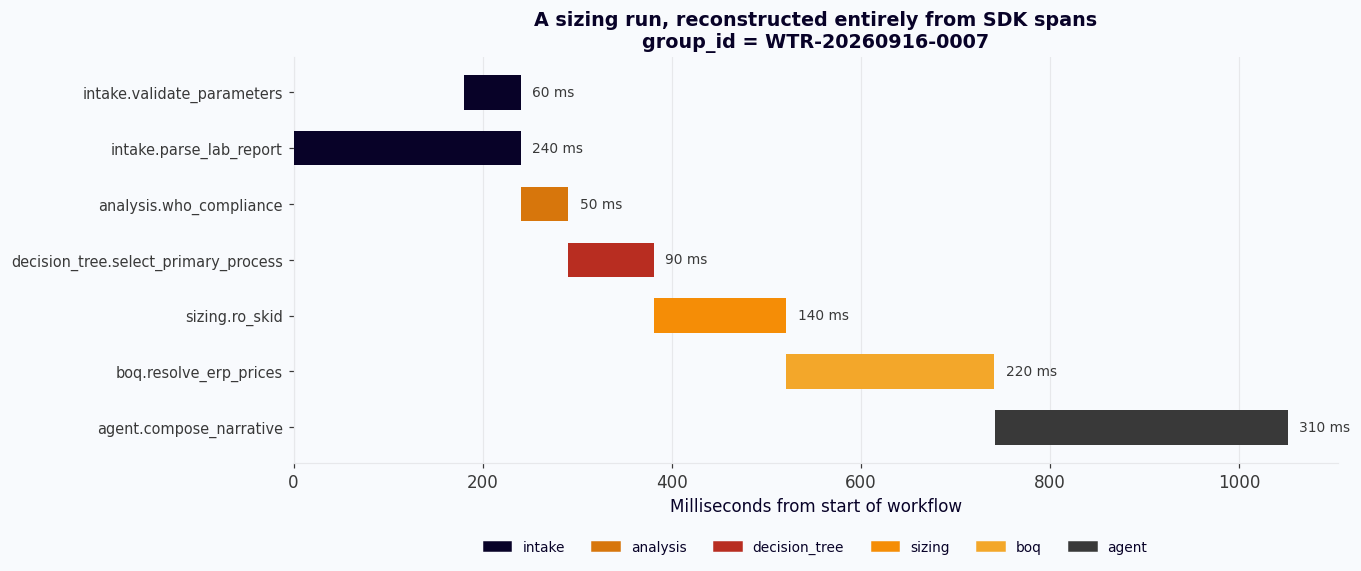

In production this chart is the 'How the AI decided' panel a sales engineer reads
before sending the quotation to a customer.


In [ ]:
from matplotlib.patches import Patch

spans = [s for s in CAPTURED if s["duration_ms"] is not None]
t0 = min(datetime.fromisoformat(str(s["started"])) for s in spans)

STAGE_COLOR = {
    "intake":        BRAND["ink"],
    "analysis":      BRAND["orange_deep"],
    "decision_tree": BRAND["maroon"],
    "sizing":        BRAND["orange"],
    "boq":           BRAND["amber"],
    "agent":         BRAND["slate"],
}

fig, ax = plt.subplots(figsize=(12.5, 5.4))
for i, s in enumerate(reversed(spans)):
    start_ms = (datetime.fromisoformat(str(s["started"])) - t0).total_seconds() * 1000
    stage = (s["name"] or "").split(".")[0]
    ax.barh(i, s["duration_ms"], left=start_ms, height=0.62, zorder=3,
            color=STAGE_COLOR.get(stage, BRAND["slate"]))
    ax.text(start_ms + s["duration_ms"] + 12, i, "{:.0f} ms".format(s["duration_ms"]),
            va="center", fontsize=9, color=BRAND["slate"])

ax.set_yticks(range(len(spans)))
ax.set_yticklabels([s["name"] for s in reversed(spans)], fontsize=9.5)
ax.set_xlabel("Milliseconds from start of workflow")
ax.set_title("A sizing run, reconstructed entirely from SDK spans\n"
             "group_id = " + WORKFLOW_ID, fontsize=12.5)
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=k) for k, c in STAGE_COLOR.items()],
          frameon=False, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.16), fontsize=9)
plt.tight_layout(); plt.show()

print("In production this chart is the 'How the AI decided' panel a sales engineer reads")
print("before sending the quotation to a customer.")

### 3.10 Lifecycle hooks

Tracing tells you what happened. **Hooks let you act while it happens.**

| Hook class | Scope | Attach via |
| --- | --- | --- |
| `RunHooks` | The whole run, across handoffs | `Runner.run(..., hooks=...)` |
| `AgentHooks` | One specific agent | `Agent(hooks=...)` |

Callbacks: `on_agent_start`, `on_agent_end`, `on_handoff`, `on_tool_start`, `on_tool_end`,
`on_llm_start`, `on_llm_end`.

The sizing engine uses both layers on purpose, and this division of labour is worth copying:

- **`DBTracingProcessor`** captures the *low-level* truth: every span, token count and latency.
- **`WorkflowRunHooks`** emits *semantic business events* (`agent.invoked`, `tool.completed`,
  `llm.call_completed`) that map onto the nine pipeline stages the frontend renders.

One stream for debugging, one for explaining. Trying to make a single stream do both is how trace
UIs become unreadable.

In [ ]:
from agents import RunHooks

class WorkshopRunHooks(RunHooks):
    """Mirror of app/services/agents_tracing_processor.py::WorkflowRunHooks."""

    def __init__(self, workflow_id):
        self.workflow_id = workflow_id
        self.events = []
        self._t = {}

    def _emit(self, kind, **payload):
        self.events.append({"workflow_id": self.workflow_id, "event": kind, **payload})
        print("  [{}] {}".format(kind, payload))

    async def on_agent_start(self, context, agent):
        self._emit("agent.invoked", agent=agent.name, tools=[t.name for t in agent.tools])

    async def on_agent_end(self, context, agent, output):
        self._emit("agent.finished", agent=agent.name, preview=str(output)[:70])

    async def on_handoff(self, context, from_agent, to_agent):
        self._emit("agent.handoff", **{"from": from_agent.name, "to": to_agent.name})

    async def on_tool_start(self, context, agent, tool):
        self._t[tool.name] = time.monotonic()
        self._emit("tool.invoked", tool=tool.name, agent=agent.name)

    async def on_tool_end(self, context, agent, tool, result):
        ms = round((time.monotonic() - self._t.pop(tool.name, time.monotonic())) * 1000, 1)
        self._emit("tool.completed", tool=tool.name, duration_ms=ms, preview=str(result)[:70])

    async def on_llm_start(self, context, agent, system_prompt, input_items):
        self._emit("llm.call_started", agent=agent.name, items=len(input_items or []))

    async def on_llm_end(self, context, agent, response):
        u = getattr(response, "usage", None)
        self._emit("llm.call_completed", agent=agent.name,
                   total_tokens=getattr(u, "total_tokens", None))


hooks = WorkshopRunHooks(WORKFLOW_ID)

if LIVE:
    print("Semantic event stream for one run:")
    await Runner.run(sizing_agent, QUESTION, hooks=hooks)
    print("\nEvents captured:", len(hooks.events))
    kinds = {}
    for e in hooks.events:
        kinds[e["event"]] = kinds.get(e["event"], 0) + 1
    for k, v in kinds.items():
        print("  {:<22} {}".format(k, v))
else:
    print("[OFFLINE] Hooks fire in this order for a tool-using run:")
    for step in ["agent.invoked", "llm.call_started", "llm.call_completed", "tool.invoked",
                 "tool.completed", "llm.call_started", "llm.call_completed", "agent.finished"]:
        print("   ->", step)

Semantic event stream for one run:
TRACE  START  Agent workflow  group_id=None
  [agent.invoked] {'agent': 'RO Sizing Assistant', 'tools': ['check_who_compliance', 'size_ro_skid']}
  [llm.call_started] {'agent': 'RO Sizing Assistant', 'items': 1}
  [llm.call_completed] {'agent': 'RO Sizing Assistant', 'total_tokens': 366}
  [tool.invoked] {'tool': 'check_who_compliance', 'agent': 'RO Sizing Assistant'}
  [tool.invoked] {'tool': 'check_who_compliance', 'agent': 'RO Sizing Assistant'}
  [tool.completed] {'tool': 'check_who_compliance', 'duration_ms': 1.0, 'preview': "{'parameter': 'tds', 'value': 1840.0, 'who_limit': 1000.0, 'verdict': "}
  [tool.completed] {'tool': 'check_who_compliance', 'duration_ms': -0.0, 'preview': "{'parameter': 'fluoride', 'value': 2.4, 'who_limit': 1.5, 'verdict': '"}
  [llm.call_started] {'agent': 'RO Sizing Assistant', 'items': 5}
  [llm.call_completed] {'agent': 'RO Sizing Assistant', 'total_tokens': 468}
  [tool.invoked] {'tool': 'size_ro_skid', 'agent': 'RO

### 3.11 Not locked in: models, hosted tools and MCP

A fair objection to any vendor SDK is lock-in. Concretely, here is how much of it there is:

**Models.** Any OpenAI-compatible endpoint works by passing a client:

```python
from agents import Agent, OpenAIChatCompletionsModel
from openai import AsyncOpenAI

model = OpenAIChatCompletionsModel(
    model="Qwen/Qwen3-235B-A22B",
    openai_client=AsyncOpenAI(base_url="https://router.huggingface.co/v1", api_key=HF_TOKEN),
)
agent = Agent(name="Narrative Agent", model=model, instructions=...)
```

That is not a hypothetical. `app/services/llm_resilience.py` uses exactly this shape: when repeated
quota errors trip a process-wide circuit breaker, `resolve_agent_model()` returns a Hugging Face
backed model instead of an OpenAI one, and **no agent, tool or trace code changes**. LiteLLM is
also supported for a long tail of other providers.

**Hosted tools** run on OpenAI's servers rather than yours: `WebSearchTool`, `FileSearchTool`,
`CodeInterpreterTool`, `ImageGenerationTool`, `ComputerTool`, `ShellTool`, `HostedMCPTool`.

**MCP** (Model Context Protocol) servers plug in via `mcp_servers=[...]`, so tools maintained by
other teams, in other languages, become available without wrapping them in Python.

### 3.12 Production checklist

Earned from running this in front of paying customers:

| Concern | What to do |
| --- | --- |
| Runaway loops | Set `max_turns` explicitly. Catch `MaxTurnsExceeded`. |
| Cost | Sum `usage` from `raw_responses`. Alert on tokens per workflow, not per request. |
| Latency | Instrument with spans, then move slow deterministic work out of the agent entirely. |
| PII in traces | `trace_include_sensitive_data=False`; ours defaults `AGENT_TRACING_INCLUDE_PROMPTS=False`. |
| Trace volume | Batch, cap payload sizes, drop under back-pressure. Never block the agent. |
| Tool failures | Decide per tool: recoverable (return the error to the model) or fatal (raise). |
| Reproducibility | Low temperature, and keep real calculations in deterministic code. |
| Prompt injection from documents | Treat extracted document text as hostile input. Validate, then guardrail. |
| Model availability | Probe models at startup; keep a fallback and a circuit breaker. |

---
<div style="background:linear-gradient(120deg,#B82D21 0%,#58250E 55%,#080228 100%);padding:24px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 4</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">Case study: 5.4 days to 10 minutes</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">The AILIFF AI Sizing Engine at Davis &amp; Shirtliff.</div>
</div>

### 4.1 The business problem

Davis &amp; Shirtliff is East Africa's leading water and energy company, operating across Kenya,
Uganda, Tanzania, Rwanda, Zambia, DRC, Ethiopia, South Sudan and Zimbabwe.

A customer sends a water lab report and asks for a treatment plant. Producing the proposal used to
mean a sales engineer:

1. Reading a dense PDF lab report, often a scan, often with the values column in 6-point type.
2. Transcribing 20-30 parameters into a spreadsheet by hand.
3. Comparing each against WHO and KEBS guidelines.
4. Deciding the treatment train: filtration, softening, ultrafiltration, reverse osmosis, dosing,
   post-treatment, and in what order.
5. Sizing every unit: membranes, pumps, filter vessels, tanks, dosing rates.
6. Looking up prices for each item in the ERP.
7. Writing the narrative, assembling the BOQ, formatting the document.
8. Queueing for a senior engineer's review.

**Elapsed time: 5.4 days.** Not 5.4 days of work; 5.4 days of calendar, because step 8 waits on the
one or two people qualified to check step 4.

Three failure modes compounded it:

- **Inconsistency.** Two engineers, one lab report, two different plants.
- **Knowledge concentration.** The decision logic lived in senior engineers' heads.
- **Lost deals.** In a competitive tender, the second-fastest quotation is often worth nothing.

Traditional  : 2592 working minutes (5.4 days x 8.0h)
With agents  : 10 minutes
Speed-up     : 259x   (99.61% reduction in turnaround)
Engineer hours released : 6,326 h / month
Indicative value        : KES 9,488,850 / month
Capacity effect         : the same team can quote ~259x more opportunities


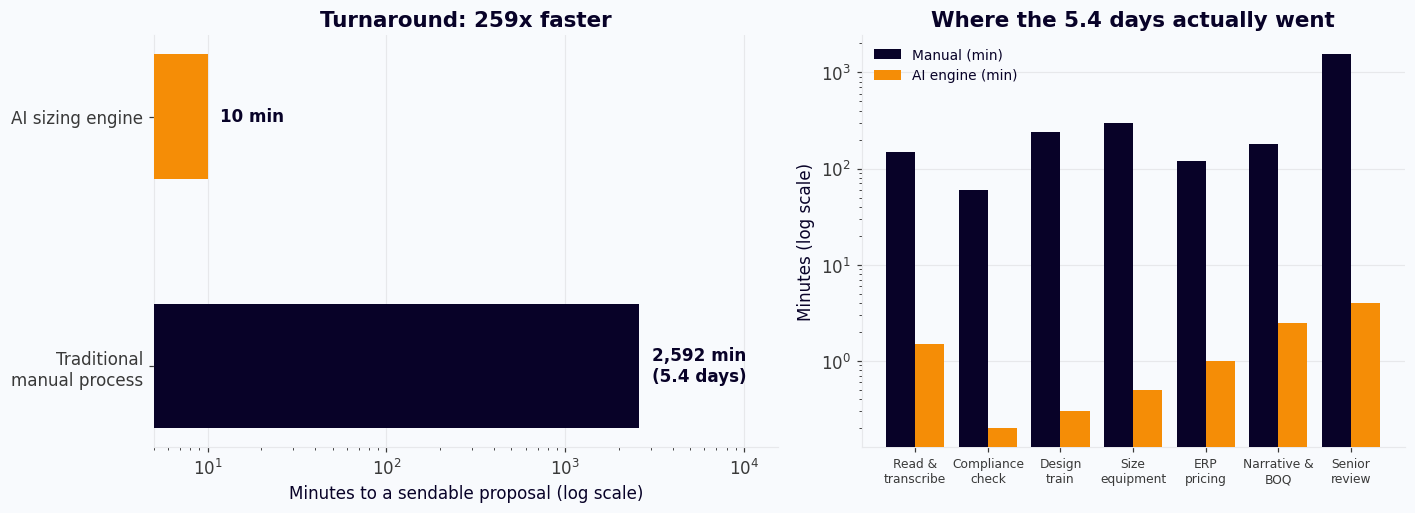


Note: the stage split is illustrative. The 5.4-day and 10-minute figures are the D&S baseline.


In [ ]:
# ---------------------------------------------------------------------------
# Edit these to match your own numbers, then re-run.
# ---------------------------------------------------------------------------
TRADITIONAL_DAYS       = 5.4      # calendar days, lab report -> proposal sent (D&S baseline)
WORK_HOURS_PER_DAY     = 8.0      # productive hours inside one calendar day
AI_MINUTES             = 10.0     # with the sizing engine
PROPOSALS_PER_MONTH    = 147      # observed proposal volume on the platform
ENGINEER_COST_PER_HOUR = 1500.0   # KES, fully loaded (placeholder - use your finance figure)

trad_min  = TRADITIONAL_DAYS * WORK_HOURS_PER_DAY * 60
speedup   = trad_min / AI_MINUTES
reduction = 100 * (1 - AI_MINUTES / trad_min)
hours_saved_month = PROPOSALS_PER_MONTH * (trad_min - AI_MINUTES) / 60
value_month       = hours_saved_month * ENGINEER_COST_PER_HOUR

print("Traditional  : {:.0f} working minutes ({} days x {}h)".format(
    trad_min, TRADITIONAL_DAYS, WORK_HOURS_PER_DAY))
print("With agents  : {:.0f} minutes".format(AI_MINUTES))
print("Speed-up     : {:.0f}x   ({:.2f}% reduction in turnaround)".format(speedup, reduction))
print("Engineer hours released : {:,.0f} h / month".format(hours_saved_month))
print("Indicative value        : KES {:,.0f} / month".format(value_month))
print("Capacity effect         : the same team can quote ~{:.0f}x more opportunities".format(speedup))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                               gridspec_kw={"width_ratios": [1.15, 1]})

bars = ax1.barh(["Traditional\nmanual process", "AI sizing engine"], [trad_min, AI_MINUTES],
                color=[BRAND["ink"], BRAND["orange"]], height=0.5, zorder=3)
ax1.bar_label(bars, labels=["{:,.0f} min\n({} days)".format(trad_min, TRADITIONAL_DAYS),
                            "{:.0f} min".format(AI_MINUTES)],
              padding=8, fontsize=11, fontweight="bold")
ax1.set_xscale("log"); ax1.set_xlim(5, trad_min * 6)
ax1.set_xlabel("Minutes to a sendable proposal (log scale)")
ax1.set_title("Turnaround: {:.0f}x faster".format(speedup))
ax1.grid(axis="y", visible=False)

stages  = ["Read &\ntranscribe", "Compliance\ncheck", "Design\ntrain", "Size\nequipment",
           "ERP\npricing", "Narrative &\nBOQ", "Senior\nreview"]
manual  = [150, 60, 240, 300, 120, 180, 1542]     # minutes, illustrative split of the 5.4 days
ai      = [1.5, 0.2, 0.3, 0.5, 1.0, 2.5, 4.0]

xs = np.arange(len(stages))
ax2.bar(xs - 0.2, manual, 0.4, label="Manual (min)", color=BRAND["ink"], zorder=3)
ax2.bar(xs + 0.2, ai,     0.4, label="AI engine (min)", color=BRAND["orange"], zorder=3)
ax2.set_yscale("log"); ax2.set_xticks(xs); ax2.set_xticklabels(stages, fontsize=8)
ax2.set_ylabel("Minutes (log scale)")
ax2.set_title("Where the 5.4 days actually went")
ax2.legend(frameon=False, fontsize=9)
ax2.grid(axis="x", visible=False)

plt.tight_layout(); plt.show()
print("\nNote: the stage split is illustrative. The 5.4-day and 10-minute figures are the D&S baseline.")

Look at the right-hand chart. The dominant bar is **senior review**, and that is the insight that
shaped the architecture:

> The bottleneck was never calculation speed. It was **waiting for a human to trust the answer.**

You cannot fix a trust bottleneck with a faster model. You fix it by making the reasoning inspectable
and the calculations deterministic. Which is why tracing and the deterministic core are the two load
-bearing decisions in this system.

### 4.2 Architecture

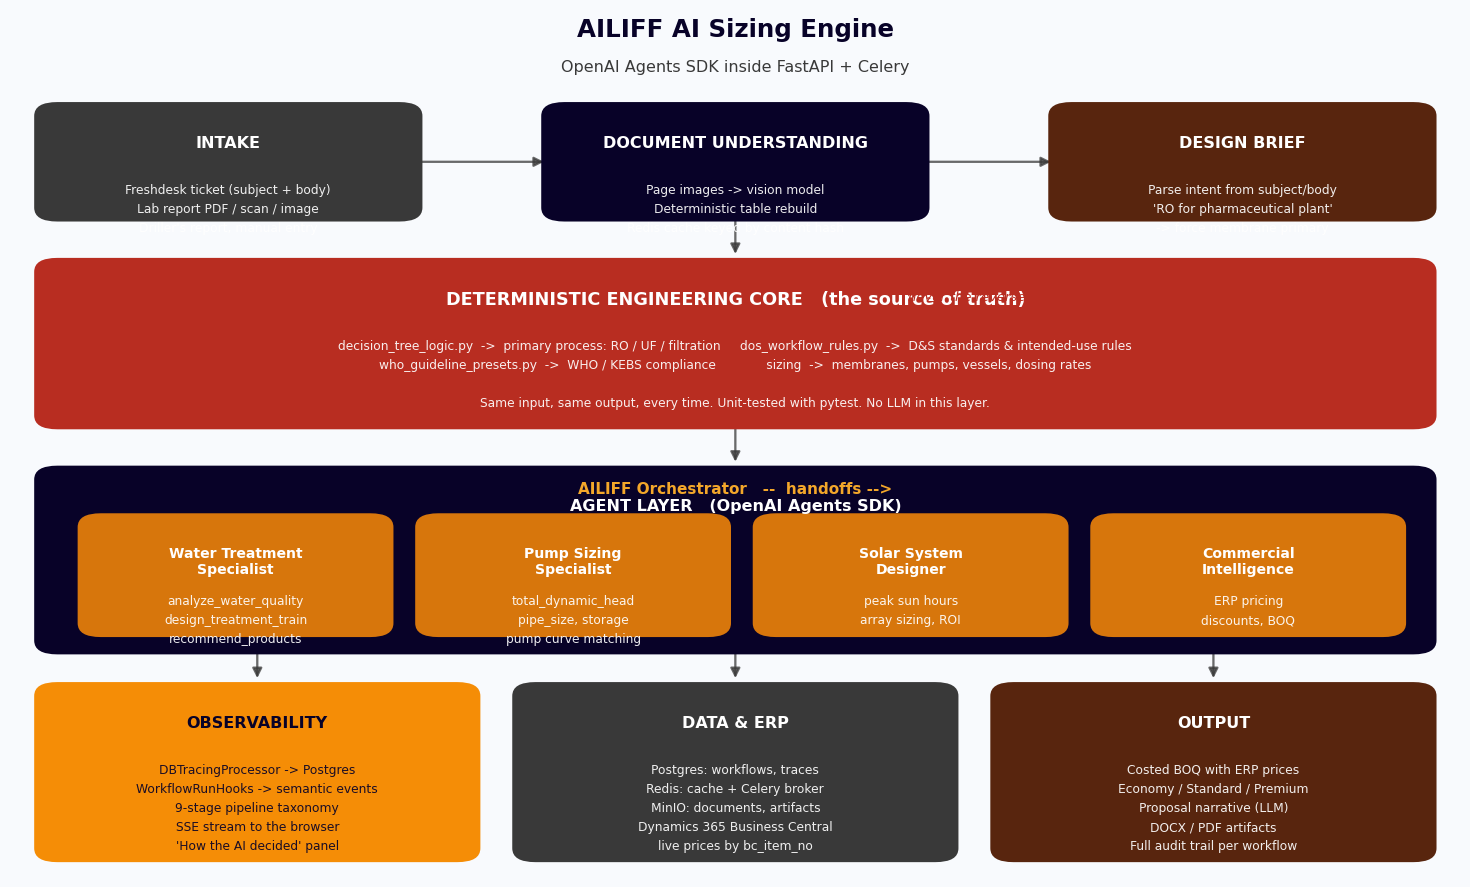

In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13.5, 8.2))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
ax.set_facecolor(BRAND["paper"])

def box(x, y, w, h, title, lines, fc, tc="#FFFFFF", fs=10.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.4,rounding_size=1.6",
                                linewidth=0, facecolor=fc, zorder=2))
    ax.text(x + w / 2, y + h - 3.4, title, ha="center", va="top", fontsize=fs,
            fontweight="bold", color=tc, zorder=3)
    if lines:
        ax.text(x + w / 2, y + h - 9.0, "\n".join(lines), ha="center", va="top",
                fontsize=8.0, color=tc, linespacing=1.6, zorder=3, alpha=0.92)

def arrow(x1, y1, x2, y2, color=None):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=13,
                                 linewidth=1.5, color=color or BRAND["slate"], zorder=1, alpha=0.75))

ax.text(50, 97, "AILIFF AI Sizing Engine", ha="center", fontsize=16, fontweight="bold",
        color=BRAND["ink"])
ax.text(50, 93, "OpenAI Agents SDK inside FastAPI + Celery", ha="center", fontsize=10.5,
        color=BRAND["slate"])

box(2,  76, 26, 13, "INTAKE", ["Freshdesk ticket (subject + body)",
                               "Lab report PDF / scan / image",
                               "Driller's report, manual entry"], BRAND["slate"])
box(37, 76, 26, 13, "DOCUMENT UNDERSTANDING",
    ["Page images -> vision model", "Deterministic table rebuild",
     "Redis cache keyed by content hash"], BRAND["ink"])
box(72, 76, 26, 13, "DESIGN BRIEF", ["Parse intent from subject/body",
                                     "'RO for pharmaceutical plant'",
                                     "-> force membrane primary"], BRAND["brown"])

box(2,  52, 96, 19, "DETERMINISTIC ENGINEERING CORE   (the source of truth)",
    ["decision_tree_logic.py  ->  primary process: RO / UF / filtration     "
     "dos_workflow_rules.py  ->  D&S standards & intended-use rules",
     "who_guideline_presets.py  ->  WHO / KEBS compliance             "
     "sizing  ->  membranes, pumps, vessels, dosing rates",
     "",
     "Same input, same output, every time. Unit-tested with pytest. No LLM in this layer."],
    BRAND["maroon"], fs=11.5)

box(2, 26, 96, 21, "AGENT LAYER   (OpenAI Agents SDK)", [], BRAND["ink"])
ax.text(50, 44.2, "AILIFF Orchestrator   --  handoffs -->", ha="center", fontsize=10,
        fontweight="bold", color=BRAND["amber"], zorder=3)
for i, (nm, tools) in enumerate([
        ("Water Treatment\nSpecialist", "analyze_water_quality\ndesign_treatment_train\nrecommend_products"),
        ("Pump Sizing\nSpecialist", "total_dynamic_head\npipe_size, storage\npump curve matching"),
        ("Solar System\nDesigner", "peak sun hours\narray sizing, ROI"),
        ("Commercial\nIntelligence", "ERP pricing\ndiscounts, BOQ")]):
    bx = 5 + i * 23.3
    box(bx, 28, 21, 13.5, nm, [tools], BRAND["orange_deep"], fs=9.2)

box(2, 2, 30, 20, "OBSERVABILITY",
    ["DBTracingProcessor -> Postgres", "WorkflowRunHooks -> semantic events",
     "9-stage pipeline taxonomy", "SSE stream to the browser",
     "'How the AI decided' panel"], BRAND["orange"], tc=BRAND["ink"])
box(35, 2, 30, 20, "DATA & ERP",
    ["Postgres: workflows, traces", "Redis: cache + Celery broker",
     "MinIO: documents, artifacts", "Dynamics 365 Business Central",
     "live prices by bc_item_no"], BRAND["slate"])
box(68, 2, 30, 20, "OUTPUT",
    ["Costed BOQ with ERP prices", "Economy / Standard / Premium",
     "Proposal narrative (LLM)", "DOCX / PDF artifacts",
     "Full audit trail per workflow"], BRAND["brown"])

arrow(28, 82.5, 37, 82.5); arrow(63, 82.5, 72, 82.5)
arrow(50, 76, 50, 71.5); arrow(50, 52, 50, 47.5)
arrow(17, 26, 17, 22.5); arrow(50, 26, 50, 22.5); arrow(83, 26, 83, 22.5)
ax.text(66, 66.5, "engineering decisions flow DOWN into the agents,\nnever the reverse",
        fontsize=8.6, style="italic", color=BRAND["maroon"], ha="center")

plt.tight_layout(); plt.show()

### 4.3 The orchestrator, for real

`app/agents/orchestrator.py` is roughly 580 lines, and almost none of it is SDK plumbing. The SDK
part is small enough to read in one breath:

```python
from agents import Agent, Runner, function_tool, handoff

class OrchestratorAgent:
    def __init__(self, model=None):
        self.model = model or settings.OPENAI_MODEL
        self.pump_agent      = create_pump_sizing_agent(model)
        self.treatment_agent = create_water_treatment_agent(model)
        self.solar_agent     = create_solar_design_agent(model)
        self.pricing_agent   = create_pricing_agent(model)
        self.agent = Agent(
            name="AILIFF Orchestrator",
            instructions=ORCHESTRATOR_AGENT_INSTRUCTIONS,
            model=self.model,
            handoffs=[handoff(agent=self.treatment_agent,
                              tool_name_override="delegate_to_treatment_specialist", ...), ...],
        )
```

The other 500 lines are the genuinely hard part, and it is not AI: **assembling the prompt**.
Before `Runner.run()` is called, `process_water_treatment_request()` gathers lab metadata, intended
use, required output, power source, and a product-knowledge context block built from Dayliff product
manuals via semantic search, ERP catalogue exports and the product database, and it degrades to a
legacy product context if that service fails.

> The framework is 5% of the work. **Context assembly is the product.** Every hour spent on
> retrieval quality paid off more than any prompt tweak.

### 4.4 The specialists and their tools

Four agents, each a real desk in the business, each with a small set of typed tools.

In [ ]:
import pandas as pd

inventory = pd.DataFrame([
    ("Water Treatment Specialist", "analyze_water_quality",             "WHO/KEBS evaluation of every parameter",  "strict_mode=False (open dict of parameters)"),
    ("Water Treatment Specialist", "design_treatment_train",            "Stage-by-stage train + chemicals",         "strict_mode=False"),
    ("Water Treatment Specialist", "recommend_water_treatment_products","Catalogue match + live ERP price",         "hits Business Central"),
    ("Pump Sizing Specialist",     "calculate_total_dynamic_head_tool", "TDH from static head + friction losses",   "pure hydraulics"),
    ("Pump Sizing Specialist",     "calculate_pipe_size",               "Pipe diameter for target velocity",        "pure hydraulics"),
    ("Pump Sizing Specialist",     "calculate_daily_water_requirement", "Demand from population / livestock / crop","pure calculation"),
    ("Pump Sizing Specialist",     "calculate_storage_tank_size",       "Storage for demand and autonomy",          "pure calculation"),
    ("Pump Sizing Specialist",     "find_matching_pumps_tool",          "Catalogue search on duty point",           "database query"),
    ("Pump Sizing Specialist",     "analyze_pump_curve",                "Efficiency at the duty point",             "curve interpolation"),
    ("Pump Sizing Specialist",     "calculate_system_curve_intersection","Operating point of pump + system",        "numeric solve"),
    ("Solar System Designer",      "peak sun hours / array sizing",     "NASA irradiance, array and ROI",           "external API + calculation"),
    ("Commercial Intelligence",    "pricing / discount / BOQ tools",    "ERP prices, tiers, BOQ assembly",          "Dynamics 365 BC"),
], columns=["Agent", "Tool", "What it does", "Notes"])

try:
    from IPython.display import display
    display(inventory.style.hide(axis="index").set_table_styles([
        {"selector": "th", "props": [("background-color", BRAND["ink"]), ("color", "#F8FAFD"),
                                     ("text-align", "left"), ("padding", "7px 11px"),
                                     ("font-family", "Inter,'Segoe UI',sans-serif")]},
        {"selector": "td", "props": [("padding", "6px 11px"), ("font-size", "12px"),
                                     ("font-family", "Inter,'Segoe UI',sans-serif")]},
    ]).set_properties(**{"border-bottom": "1px solid " + BRAND["mist"]}))
except Exception:
    print(inventory.to_string(index=False))

print("\nEvery one of these wraps a plain Python function that existed before the AI project began.")

Agent,Tool,What it does,Notes
Water Treatment Specialist,analyze_water_quality,WHO/KEBS evaluation of every parameter,strict_mode=False (open dict of parameters)
Water Treatment Specialist,design_treatment_train,Stage-by-stage train + chemicals,strict_mode=False
Water Treatment Specialist,recommend_water_treatment_products,Catalogue match + live ERP price,hits Business Central
Pump Sizing Specialist,calculate_total_dynamic_head_tool,TDH from static head + friction losses,pure hydraulics
Pump Sizing Specialist,calculate_pipe_size,Pipe diameter for target velocity,pure hydraulics
Pump Sizing Specialist,calculate_daily_water_requirement,Demand from population / livestock / crop,pure calculation
Pump Sizing Specialist,calculate_storage_tank_size,Storage for demand and autonomy,pure calculation
Pump Sizing Specialist,find_matching_pumps_tool,Catalogue search on duty point,database query
Pump Sizing Specialist,analyze_pump_curve,Efficiency at the duty point,curve interpolation
Pump Sizing Specialist,calculate_system_curve_intersection,Operating point of pump + system,numeric solve



Every one of these wraps a plain Python function that existed before the AI project began.


### 4.5 The decision that made it work

Here is the thing most agentic AI demos get wrong, and it is the reason many of them never reach
production.

<div style="background:#080228;color:#F8FAFD;padding:22px 26px;border-radius:10px;
     border-left:6px solid #F58D06;font-family:Inter,'Segoe UI',sans-serif;font-size:15px;
     line-height:1.65">
<b style="color:#F3A72A">The LLM does not choose the treatment process.</b><br>
Whether a plant gets reverse osmosis, ultrafiltration or plain filtration is decided by
<code style="color:#F3A72A">decision_tree_logic.py</code>, a deterministic rule engine encoding
Davis &amp; Shirtliff engineering standards and WHO limits. The model reads that decision,
<i>explains</i> it, and assembles the document around it.
</div>

The split of responsibilities:

| Task | Owner | Why |
| --- | --- | --- |
| Read a messy PDF lab report | **LLM (vision)** | Genuinely hard perception, tolerant of ambiguity |
| Normalise parameter names and units | Code + LLM gap-fill | Deterministic first, model only for what is missing |
| Compare against WHO / KEBS | **Code** | Regulatory. Must be identical every time. |
| Choose RO vs UF vs filtration | **Code** | Engineering liability. Must be defensible and auditable. |
| Size membranes, pumps, vessels | **Code** | Spec-sheet arithmetic. Models have no business here. |
| Resolve SKUs and ERP prices | **Code** | Financial correctness |
| Decide which specialist handles a request | **LLM** | Fuzzy routing, exactly what models are good at |
| Understand intent in a customer email | **LLM** | Unstructured language |
| Write the proposal narrative | **LLM** | Fluent, context-aware prose at scale |

Two payoffs, both large:

1. **Reproducibility.** The same lab report yields the same plant, today and in six months. You
   cannot sell engineering that does not.
2. **The system still works when the model is down.** Because the core is callable directly, a
   proposal can be produced with zero LLM involvement. The AI degrades the narrative, not the
   engineering.

### 4.6 The unglamorous 60%: reading the lab report

A confession that will save you months. The hardest part of this project was not the agents. It was
**reading a PDF.**

Davis &amp; Shirtliff lab reports arrive in a six-column layout: `PARAMETERS | METHOD OF ANALYSIS |
UNITS | VALUES | WHO GUIDELINES`. Real failure modes we hit, all from actual customer reports:

- **The catastrophic one:** extracting the *WHO guideline* column instead of the *VALUES* column.
  The report says 1,840 mg/L TDS; you read the 1,000 mg/L limit; you size a plant that cannot
  treat the water. Silent, plausible, wrong.
- Scanned reports where PyMuPDF concatenates several table rows into one text blob.
- 6-point print a human has to zoom in to read, which is also why the vision path renders pages at
  `zoom=3.0` and JPEG quality 90 rather than the default.
- `pH` appearing as both a parameter name and a unit, splitting rows in the wrong place.
- Values written as `<0.01`, which is not a float.

How it was eventually made reliable, and this pipeline is the transferable lesson:

1. **Render pages as high-resolution images and let a vision model read them the way a human does
   after zooming in.** Native text extraction alone was not enough for dense small print.
2. **Run a deterministic regex and table reconstructor in parallel**, with explicit rules such as
   "the reading appears *before* the guideline value on the line".
3. **Reconcile.** If the model returns zero parameters, seed from the deterministic parse. If it
   returns some, overlay the deterministic result to fill gaps.
4. **Never cache a failure.** The extraction cache is keyed by document content hash, but a lab
   report that yields zero parameters is not stored, so a bug fix does not have to fight stale cache
   entries.
5. **Fail loudly.** A run that extracts no parameters now returns `status: failed`, not a cheerful
   "Done" with an empty table. Silent success is the worst outcome in a sizing tool.

> Budget your project accordingly: in our experience roughly **60% document understanding, 25%
> deterministic engineering rules, 15% agents.** The agentic layer is the smallest and most
> enjoyable part.

### 4.7 Tracing in production

`app/services/agents_tracing_processor.py` is the `TracingProcessor` from Part 3.9, hardened. The
design constraints are worth stating because they generalise to any agent system:

```python
class DBTracingProcessor(TracingProcessor):
    # 1. Callbacks are on the agent's hot path -> only enqueue lightweight dicts
    # 2. A bounded queue drops OLDEST events under pressure, never blocks the run
    # 3. A background thread flushes batches to Postgres with its own DB session,
    #    so an exhausted API connection pool cannot stall tracing
    # 4. Every callback swallows Exception - a trace bug must never break a sizing run
    # 5. trace.group_id == our workflow_id, so spans join the business record for free
```

Operational knobs, all in `app/config.py`:

| Setting | Default | Why |
| --- | --- | --- |
| `AGENT_TRACING_ENABLED` | `True` | Master switch |
| `AGENT_TRACING_DB_BATCH_SIZE` | `20` | Rows per transaction |
| `AGENT_TRACING_DB_FLUSH_INTERVAL_SECONDS` | `1.5` | Latency vs write amplification |
| `AGENT_TRACING_QUEUE_MAX_SIZE` | `4096` | Back-pressure ceiling |
| `AGENT_TRACING_INCLUDE_PROMPTS` | `False` | **Keeps customer PII out of the trace store** |
| `AGENT_TRACING_TEXT_PREVIEW_CHARS` | `2000` | Stops multi-megabyte rows |

Raw spans are not what an engineer wants to read, though. A second layer buckets every event into
nine ordered pipeline stages, and that is what the UI renders.

In [ ]:
stages = pd.DataFrame([
    ("1", "Workflow",             "workflow.*",                        "Lifecycle: start, completion, errors"),
    ("2", "Inputs & Parameters",  "pipeline.parameters, pipeline.lab_report", "Lab parsing, parameter resolution, flow, intended use"),
    ("3", "Water Quality Analysis","analysis.*, pipeline.exceed",       "WHO/KEBS compliance, exceedances"),
    ("4", "Engineering Decision Tree","decision.*, engineering.*",      "Deterministic RO vs UF vs filtration, filter and softener classes"),
    ("5", "Equipment Sizing",     "sizing.*, pump.*, ro.*, uf.*",       "Pump selection, skid sizing, dosing rates"),
    ("6", "BOQ & ERP Resolution", "boq.*, erp.*",                       "Resolved SKUs, ERP prices, deduplication"),
    ("7", "Treatment Options",    "option.*, positioning.*",            "Economy / Standard / Premium tiers"),
    ("8", "AI Narrative (LLM)",   "agent.*, llm.*, tool.*, agent_sdk.*", "SDK spans, tool calls, narrative composition"),
    ("9", "Delivery",             "proposal.*, docx.*, pdf.*",          "Completion, document generation, artifact links"),
], columns=["#", "Stage", "Event prefixes", "What the engineer sees"])

try:
    from IPython.display import display
    display(stages.style.hide(axis="index").set_table_styles([
        {"selector": "th", "props": [("background-color", BRAND["maroon"]), ("color", "#F8FAFD"),
                                     ("text-align", "left"), ("padding", "7px 11px"),
                                     ("font-family", "Inter,'Segoe UI',sans-serif")]},
        {"selector": "td", "props": [("padding", "6px 11px"), ("font-size", "12px"),
                                     ("font-family", "Inter,'Segoe UI',sans-serif")]},
    ]).set_properties(**{"border-bottom": "1px solid " + BRAND["mist"]}))
except Exception:
    print(stages.to_string(index=False))

print("""
Exposed over HTTP for the frontend:
  GET /api/v1/traces/{workflow_id}            raw ordered events
  GET /api/v1/traces/breakdown/{workflow_id}  events bucketed into the nine stages
  GET /api/v1/traces/summary/{workflow_id}    counts, timings, token usage
  GET /api/v1/traces/stream/{workflow_id}     Server-Sent Events, live as the agent works
  GET /api/v1/traces/health                   confirms the processor was installed

The SSE stream is why a sales engineer watching a 10-minute run does not see a spinner.
They watch the engine think, stage by stage. That visibility is what earned the tool its trust.
""")

#,Stage,Event prefixes,What the engineer sees
1,Workflow,workflow.*,"Lifecycle: start, completion, errors"
2,Inputs & Parameters,"pipeline.parameters, pipeline.lab_report","Lab parsing, parameter resolution, flow, intended use"
3,Water Quality Analysis,"analysis.*, pipeline.exceed","WHO/KEBS compliance, exceedances"
4,Engineering Decision Tree,"decision.*, engineering.*","Deterministic RO vs UF vs filtration, filter and softener classes"
5,Equipment Sizing,"sizing.*, pump.*, ro.*, uf.*","Pump selection, skid sizing, dosing rates"
6,BOQ & ERP Resolution,"boq.*, erp.*","Resolved SKUs, ERP prices, deduplication"
7,Treatment Options,"option.*, positioning.*",Economy / Standard / Premium tiers
8,AI Narrative (LLM),"agent.*, llm.*, tool.*, agent_sdk.*","SDK spans, tool calls, narrative composition"
9,Delivery,"proposal.*, docx.*, pdf.*","Completion, document generation, artifact links"



Exposed over HTTP for the frontend:
  GET /api/v1/traces/{workflow_id}            raw ordered events
  GET /api/v1/traces/breakdown/{workflow_id}  events bucketed into the nine stages
  GET /api/v1/traces/summary/{workflow_id}    counts, timings, token usage
  GET /api/v1/traces/stream/{workflow_id}     Server-Sent Events, live as the agent works
  GET /api/v1/traces/health                   confirms the processor was installed

The SSE stream is why a sales engineer watching a 10-minute run does not see a spinner.
They watch the engine think, stage by stage. That visibility is what earned the tool its trust.



### 4.8 Resilience: what production actually demanded

None of these were in the original design. All of them turned out to be mandatory.

| Problem met in the wild | Response |
| --- | --- |
| A model name silently unavailable on the org | Probe configured models at startup, log a usable fallback |
| Quota and billing errors mid-run | Process-wide **circuit breaker**; skip OpenAI for a cooldown |
| Need to keep running when OpenAI is unavailable | Reroute to open-weights models via an OpenAI-compatible HF router |
| Cold starts on fallback providers | Warm-up ping per model at startup, plus cold-start retry with backoff |
| Re-parsing identical documents | Redis extraction cache keyed by content hash, with a version prefix so logic changes invalidate cleanly |
| A bad parse poisoning the cache | Never cache a zero-parameter lab extraction |
| Wrong recommendation, no recourse | **A rerun endpoint**, plus explicit overrides |

That last row deserves its own story, because it is the most instructive failure in the project.

#### The pharmaceutical RO incident

A ticket arrived titled **"RO Proposal for Pharmaceutical plant in DRC"**. The body was a complete
specification: 10,000 L/h pre-treatment, 5,000 L/h purified water, European Pharmacopoeia Monograph
0008, conductivity not more than 2.0 microsiemens/cm, TOC not more than 0.5 mg/L, a Siemens S7-1200
PLC with 30 days of historised data.

The engine recommended **filtration**. Not RO.

It was not a hallucination. It was, technically, correct: the attached lab report showed TDS below
the threshold at which the decision tree calls for a membrane, so the deterministic rules did
exactly what they were written to do. The system had read the *attachment* and ignored the
*request*.

The fix was not a better model or a better prompt:

- A new `app/services/design_brief.py` parses the ticket subject and body for explicit design
  constraints: requested process, intended use, product flow, target conductivity and TDS, TOC.
- Pharmaceutical or purified-water intent now sets `force_membrane_primary=True`, so the decision
  tree is *told* that a membrane is mandatory regardless of feed TDS.
- Product flow (5,000 L/h of purified water) is distinguished from pre-treatment flow (10,000 L/h),
  because sizing on the wrong one quietly doubles the plant.
- A `POST /water-treatment/recommendations/rerun` endpoint re-runs a previous `workflow_id` with
  corrected or forced inputs.
- Tests pinned the behaviour: `tests/test_design_brief_pharma_ro.py`.

**The lesson, which is general:** in agentic systems, *intent stated in the request is data too*.
We had built a careful pipeline for the attachment and treated the human's own words as decoration.
And when a deterministic core gets it wrong, the answer is an **override and rerun path**, not
loosening the determinism.

### 4.9 Outcomes

| Dimension | Before | After |
| --- | --- | --- |
| Turnaround, lab report to proposal | **5.4 days** | **about 10 minutes** |
| Consistency | Engineer-dependent | Deterministic core: same input, same plant |
| Compliance checking | Manual, per parameter | Automatic against WHO / KEBS presets |
| Pricing | Manual ERP lookups | Live Business Central prices per `bc_item_no` |
| Auditability | An engineer's memory | Full span-level trace per `workflow_id` |
| Knowledge | In senior engineers' heads | Encoded, versioned, unit-tested, reviewable in git |
| Options offered | Usually one | Economy / Standard / Premium tiers |
| Who can produce a proposal | Senior engineers | Any sales engineer, with review |

The strategic outcome is the last row. Encoding senior engineering judgement into
`decision_tree_logic.py` turned a scarce skill into infrastructure, and that is worth more than the
259x speed-up.

### 4.10 Lessons, compressed

**Do**

1. Put the truth in deterministic code. Use the model for perception, routing and prose.
2. Keep a `_core` function plus a thin `@function_tool` wrapper. Test the core with `pytest`.
3. Trace to your own store from day one, and show the trace to your users, not just your engineers.
4. Set `group_id` to your business key. Correlation you get for free is correlation you will use.
5. Treat tool docstrings as prompt engineering.
6. Assume documents lie. Validate extraction against the source text deterministically.
7. Build a rerun and override path before you need it. You will need it.
8. Default to excluding prompts and outputs from persisted traces, then opt in for debugging.

**Do not**

1. Do not let a model do arithmetic a spec sheet can answer.
2. Do not cache an empty or failed extraction.
3. Do not report success when zero parameters were extracted. Fail loudly.
4. Do not block the agent's hot path with trace writes.
5. Do not read only the attachment. Read the subject and body too.
6. Do not chase framework purity. `openai-agents` and `langgraph` coexist in our requirements.
7. Do not present agent output as fact without a path back to the evidence.

---
<div style="background:#080228;padding:22px 28px;border-radius:12px;border-left:6px solid #F58D06;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;color:#F58D06;font-weight:700">Part 5</div>
  <div style="font-size:30px;font-weight:800;margin-top:6px">Build it yourself</div>
  <div style="font-size:14px;opacity:.75;margin-top:8px">A miniature sizing engine with every lesson from Part 4 baked in.</div>
</div>

This last section assembles everything: deterministic core, thin tool wrappers, a guardrail,
structured output, custom spans and a `group_id` tied to a workflow.

It follows the **core plus wrapper** pattern, so the engineering functions run identically with or
without an API key. Offline participants still get a complete, correct sizing.

In [ ]:
from typing import Dict, List, Literal, Optional
from pydantic import BaseModel, Field

# =============================================================================
# LAYER 1: DETERMINISTIC ENGINEERING CORE - no LLM, no SDK, pure Python
# =============================================================================
WHO_LIMITS = {"tds": 1000.0, "fluoride": 1.5, "nitrate": 50.0, "iron": 0.3,
              "manganese": 0.4, "turbidity": 5.0, "hardness": 500.0, "chloride": 250.0}

# Parameters that can only be removed by a membrane.
MEMBRANE_ONLY = {"tds", "fluoride", "nitrate", "chloride"}


def evaluate_parameters_core(parameters: Dict[str, float]) -> dict:
    """Compare every measured parameter against its WHO guideline."""
    rows, exceedances = [], []
    for name, value in parameters.items():
        limit = WHO_LIMITS.get(name.lower())
        verdict = "NO_GUIDELINE" if limit is None else ("PASS" if value <= limit else "FAIL")
        rows.append({"parameter": name, "value": value, "who_limit": limit, "verdict": verdict})
        if verdict == "FAIL":
            exceedances.append(name.lower())
    return {"rows": rows, "exceedances": exceedances,
            "compliant": len(exceedances) == 0}


def select_primary_process_core(parameters: Dict[str, float],
                                intended_use: str = "drinking",
                                force_membrane: bool = False) -> dict:
    """THE decision. Deterministic, explainable, and the model never gets a vote.

    Mirrors the shape of decision_tree_logic.py in the production engine.
    """
    ev = evaluate_parameters_core(parameters)
    exceed = set(ev["exceedances"])
    use = (intended_use or "").lower()

    # Rule 0: stated intent can mandate a membrane regardless of feed quality.
    # This rule exists because of the pharmaceutical RO incident in section 4.8.
    if force_membrane or any(k in use for k in ("pharma", "purified", "bottl", "dialysis")):
        return {"primary_process": "RO", "rule": "intended use '{}' mandates a membrane".format(intended_use),
                "exceedances": sorted(exceed), "forced": True}

    # Rule 1: dissolved salts require reverse osmosis.
    membrane_drivers = exceed & MEMBRANE_ONLY
    if membrane_drivers:
        return {"primary_process": "RO",
                "rule": "dissolved contaminant(s) {} exceed WHO limits and cannot be filtered".format(
                    sorted(membrane_drivers)),
                "exceedances": sorted(exceed), "forced": False}

    # Rule 2: microbiological or particulate risk only -> ultrafiltration.
    if exceed & {"turbidity", "iron", "manganese"}:
        return {"primary_process": "UF",
                "rule": "particulate/metal exceedances removable by ultrafiltration",
                "exceedances": sorted(exceed), "forced": False}

    # Rule 3: compliant feed -> polish only.
    return {"primary_process": "FILTRATION", "rule": "feed is WHO compliant; polishing only",
            "exceedances": sorted(exceed), "forced": False}


def size_plant_core(primary_process: str, permeate_m3_h: float,
                    feed_tds_mg_l: float = 500.0) -> dict:
    """Spec-sheet arithmetic. Deliberately boring."""
    if primary_process == "RO":
        recovery = 0.5 if feed_tds_mg_l > 1500 else 0.6
        feed = permeate_m3_h / recovery
        stages = [("Raw water pump", 1), ("Multimedia filter", 1), ("Activated carbon filter", 1),
                  ("Antiscalant dosing", 1), ("5 micron cartridge filter", 1),
                  ("RO high pressure pump", 1), ("RO membranes 4040", max(1, round(permeate_m3_h / 0.55))),
                  ("Permeate tank", 1), ("UV steriliser", 1)]
    elif primary_process == "UF":
        recovery, feed = 0.9, permeate_m3_h / 0.9
        stages = [("Raw water pump", 1), ("Multimedia filter", 1),
                  ("UF membrane module", max(1, round(permeate_m3_h / 2.0))),
                  ("Backwash pump", 1), ("Chlorine dosing", 1), ("Treated water tank", 1)]
    else:
        recovery, feed = 1.0, permeate_m3_h
        stages = [("Multimedia filter", 1), ("Activated carbon filter", 1), ("UV steriliser", 1)]
    return {"primary_process": primary_process, "recovery": recovery,
            "permeate_m3_h": permeate_m3_h, "feed_m3_h": round(feed, 2),
            "equipment": [{"item": n, "qty": q} for n, q in stages]}


PRICE_BOOK = {"Raw water pump": 95_000, "Multimedia filter": 210_000,
              "Activated carbon filter": 185_000, "Antiscalant dosing": 78_000,
              "5 micron cartridge filter": 24_000, "RO high pressure pump": 320_000,
              "RO membranes 4040": 62_000, "Permeate tank": 88_000, "UV steriliser": 96_000,
              "UF membrane module": 240_000, "Backwash pump": 84_000,
              "Chlorine dosing": 65_000, "Treated water tank": 74_000}


def price_boq_core(equipment: List[dict], currency: str = "KES") -> dict:
    """Stands in for a Business Central lookup by bc_item_no."""
    lines, total = [], 0
    for item in equipment:
        unit = PRICE_BOOK.get(item["item"], 0)
        line = unit * item["qty"]
        total += line
        lines.append({**item, "unit_price": unit, "line_total": line})
    return {"currency": currency, "lines": lines, "subtotal": total,
            "vat_16pct": round(total * 0.16), "total": round(total * 1.16)}


# ---- Prove the core stands alone --------------------------------------------
SAMPLE_LAB_REPORT = {"tds": 1840.0, "fluoride": 2.4, "nitrate": 12.0,
                     "iron": 0.18, "turbidity": 3.1, "hardness": 320.0}

decision = select_primary_process_core(SAMPLE_LAB_REPORT, intended_use="drinking")
plant    = size_plant_core(decision["primary_process"], 6.0, SAMPLE_LAB_REPORT["tds"])
boq      = price_boq_core(plant["equipment"])

print("DETERMINISTIC CORE, NO LLM INVOLVED")
print("  process   :", decision["primary_process"])
print("  rule      :", decision["rule"])
print("  feed flow : {} m3/h for {} m3/h permeate".format(plant["feed_m3_h"], plant["permeate_m3_h"]))
print("  BOQ lines :", len(boq["lines"]))
print("  total     : {} {:,}".format(boq["currency"], boq["total"]))

DETERMINISTIC CORE, NO LLM INVOLVED
  process   : RO
  rule      : dissolved contaminant(s) ['fluoride', 'tds'] exceed WHO limits and cannot be filtered
  feed flow : 12.0 m3/h for 6.0 m3/h permeate
  BOQ lines : 9
  total     : KES 2,062,480


In [ ]:
# =============================================================================
# LAYER 2: THIN TOOL WRAPPERS - the only code the agent sees
# =============================================================================
from agents import (Agent, GuardrailFunctionOutput, RunConfig, Runner,
                    function_tool, input_guardrail, custom_span, trace)

@function_tool(strict_mode=False)
def evaluate_parameters(parameters: Dict[str, float]) -> dict:
    """Compare measured water quality parameters against WHO guideline values.

    Args:
        parameters: Mapping of parameter name to measured value, e.g. {'tds': 1840, 'fluoride': 2.4}.
    """
    with custom_span("analysis.who_compliance", data={"n_parameters": len(parameters)}):
        return evaluate_parameters_core(parameters)


@function_tool(strict_mode=False)
def select_primary_process(parameters: Dict[str, float], intended_use: str = "drinking",
                           force_membrane: bool = False) -> dict:
    """Select the primary treatment process using the deterministic engineering decision tree.

    Args:
        parameters: Mapping of parameter name to measured value.
        intended_use: e.g. 'drinking', 'bottling', 'pharmaceutical', 'irrigation'.
        force_membrane: Set True when the customer explicitly requires a membrane plant.
    """
    out = select_primary_process_core(parameters, intended_use, force_membrane)
    with custom_span("decision_tree.select_primary_process", data=out):
        return out


@function_tool
def size_plant(primary_process: str, permeate_m3_h: float, feed_tds_mg_l: float = 500.0) -> dict:
    """Size the treatment plant once the primary process is known.

    Args:
        primary_process: One of 'RO', 'UF', 'FILTRATION'.
        permeate_m3_h: Required treated water flow in m3/h.
        feed_tds_mg_l: Feed TDS in mg/L, used to set recovery.
    """
    out = size_plant_core(primary_process, permeate_m3_h, feed_tds_mg_l)
    with custom_span("sizing.plant", data={"process": primary_process,
                                           "items": len(out["equipment"])}):
        return out


@function_tool(strict_mode=False)
def price_boq(equipment: List[dict]) -> dict:
    """Price a bill of quantities from the ERP price book.

    Args:
        equipment: List of {'item': name, 'qty': n} entries from size_plant.
    """
    out = price_boq_core(equipment)
    with custom_span("boq.resolve_erp_prices", data={"lines": len(out["lines"]),
                                                     "total": out["total"]}):
        return out


# ---- Guardrail --------------------------------------------------------------
@input_guardrail
async def water_requests_only(ctx, agent, user_input) -> GuardrailFunctionOutput:
    """Cheap, deterministic topicality check before any model spend."""
    text = (user_input if isinstance(user_input, str) else str(user_input)).lower()
    hits = sorted(t for t in WATER_TERMS if t in text)
    return GuardrailFunctionOutput(output_info={"matched_terms": hits},
                                   tripwire_triggered=not hits)


# ---- Structured output ------------------------------------------------------
class MiniProposal(BaseModel):
    client: str = Field(description="Client or site name if stated, else 'Unknown'")
    primary_process: Literal["RO", "UF", "FILTRATION"]
    deciding_rule: str = Field(description="Verbatim rule returned by select_primary_process")
    exceedances: List[str]
    permeate_m3_h: float
    feed_m3_h: float
    boq_total: float
    currency: str
    narrative: str = Field(description="Two to four sentences a sales engineer can send as-is")


mini_engine = Agent(
    name="Mini Sizing Engine",
    instructions=(
        "You size water treatment plants for Davis & Shirtliff.\n"
        "Follow this order strictly and use a tool at every step:\n"
        "  1. evaluate_parameters  2. select_primary_process  3. size_plant  4. price_boq\n"
        "Never choose the process yourself: report what select_primary_process returned and quote "
        "its rule verbatim in deciding_rule. Never invent prices or flows.\n"
        "If the request states an intended use such as pharmaceutical or bottling, pass it through."
    ),
    model=DEMO_MODEL,
    tools=[evaluate_parameters, select_primary_process, size_plant, price_boq],
    input_guardrails=[water_requests_only],
    output_type=MiniProposal,
)

print("Mini engine ready.")
print("  tools     :", [t.name for t in mini_engine.tools])
print("  guardrails:", [g.get_name() for g in mini_engine.input_guardrails])
print("  output    :", MiniProposal.__name__)

Mini engine ready.
  tools     : ['evaluate_parameters', 'select_primary_process', 'size_plant', 'price_boq']
  guardrails: ['water_requests_only']
  output    : MiniProposal


In [ ]:
# =============================================================================
# RUN IT, fully traced
# =============================================================================
CAPTURED.clear()
MINI_WORKFLOW_ID = "WTR-WORKSHOP-0001"

REQUEST = """
Client: Shalom Civic Home, Kiambu.
Borehole analysis: TDS 1,840 mg/L, fluoride 2.4 mg/L, nitrate 12 mg/L,
iron 0.18 mg/L, turbidity 3.1 NTU, hardness 320 mg/L.
Intended use: drinking water for a 400-bed facility. We need 6 m3/h of treated water.
Please size the plant and give me a costed BOQ.
"""

run_config = RunConfig(
    workflow_name="Mini Sizing Engine",
    group_id=MINI_WORKFLOW_ID,
    trace_metadata={"client": "Shalom Civic Home", "channel": "workshop"},
    trace_include_sensitive_data=False,
)

if LIVE:
    result = await Runner.run(mini_engine, REQUEST, run_config=run_config,
                              hooks=WorkshopRunHooks(MINI_WORKFLOW_ID), max_turns=12)
    p = result.final_output
    print("\n" + "=" * 74)
    print("PROPOSAL  |  {}".format(p.client))
    print("=" * 74)
    print("Primary process : {}".format(p.primary_process))
    print("Deciding rule   : {}".format(p.deciding_rule))
    print("Exceedances     : {}".format(", ".join(p.exceedances) or "none"))
    print("Flow            : {} m3/h permeate from {} m3/h feed".format(p.permeate_m3_h, p.feed_m3_h))
    print("BOQ total       : {} {:,.0f}".format(p.currency, p.boq_total))
    print("\n{}".format(p.narrative))
    print("\nModel turns: {} | Spans captured: {}".format(len(result.raw_responses), len(CAPTURED)))
else:
    print("[OFFLINE] The deterministic core produces the whole proposal without a model:\n")
    with trace("Mini Sizing Engine", group_id=MINI_WORKFLOW_ID):
        with custom_span("analysis.who_compliance", data={"n": len(SAMPLE_LAB_REPORT)}):
            ev = evaluate_parameters_core(SAMPLE_LAB_REPORT)
        with custom_span("decision_tree.select_primary_process"):
            d = select_primary_process_core(SAMPLE_LAB_REPORT, "drinking")
        with custom_span("sizing.plant"):
            pl = size_plant_core(d["primary_process"], 6.0, SAMPLE_LAB_REPORT["tds"])
        with custom_span("boq.resolve_erp_prices"):
            bq = price_boq_core(pl["equipment"])

    print("  process     :", d["primary_process"])
    print("  rule        :", d["rule"])
    print("  exceedances :", ", ".join(ev["exceedances"]))
    print("  flow        : {} m3/h permeate from {} m3/h feed".format(
        pl["permeate_m3_h"], pl["feed_m3_h"]))
    print("  BOQ total   : {} {:,}".format(bq["currency"], bq["total"]))
    print("\n  Spans captured by our processor:", len(CAPTURED))
    for s in CAPTURED:
        print("    {:>7} ms  {}".format(s["duration_ms"], s["name"]))
    print("\n  Only the NARRATIVE needs the LLM. That is the whole architectural point.")

TRACE  START  Mini Sizing Engine  group_id=WTR-WORKSHOP-0001
  [agent.invoked] {'agent': 'Mini Sizing Engine', 'tools': ['evaluate_parameters', 'select_primary_process', 'size_plant', 'price_boq']}
  [llm.call_started] {'agent': 'Mini Sizing Engine', 'items': 1}
  [llm.call_completed] {'agent': 'Mini Sizing Engine', 'total_tokens': 889}
  [tool.invoked] {'tool': 'evaluate_parameters', 'agent': 'Mini Sizing Engine'}
  [tool.invoked] {'tool': 'select_primary_process', 'agent': 'Mini Sizing Engine'}
  [tool.completed] {'tool': 'select_primary_process', 'duration_ms': 1.6, 'preview': '{\'primary_process\': \'RO\', \'rule\': "dissolved contaminant(s) [\'fluoride'}
  [tool.completed] {'tool': 'evaluate_parameters', 'duration_ms': 1.7, 'preview': "{'rows': [{'parameter': 'tds', 'value': 1840.0, 'who_limit': 1000.0, '"}
  [llm.call_started] {'agent': 'Mini Sizing Engine', 'items': 5}
  [llm.call_completed] {'agent': 'Mini Sizing Engine', 'total_tokens': 1184}
  [tool.invoked] {'tool': 'size_pl

### Exercises

1. **Break the decision tree's determinism deliberately.** Remove `select_primary_process` from
   `tools` and change the instructions to "decide the process yourself". Run it five times on the
   same request. Count how many different plants you get, then explain to yourself why that is
   unsellable.
2. **Reproduce the pharmaceutical incident.** Run the request with
   `intended_use: pharmaceutical` but lower TDS to 400 mg/L. Confirm Rule 0 still forces RO, then
   delete Rule 0 and watch the engine confidently recommend filtration for a pharmaceutical plant.
3. **Write a real `TracingProcessor`.** Extend `WorkshopProcessor` to write to SQLite and add a
   `get_breakdown(workflow_id)` function that buckets spans into stages like section 4.7.
4. **Add an output guardrail** that rejects any `MiniProposal` whose `deciding_rule` does not
   appear verbatim in a `select_primary_process` tool output. This is how you mechanically stop a
   model from paraphrasing an engineering justification.
5. **Add a fifth tool** for solar power sizing and expose the mini engine as a specialist behind an
   orchestrator with `handoff(...)`. Watch the handoff span appear in your trace.

---
## Resources

**OpenAI Agents SDK**
- Documentation: <https://openai.github.io/openai-agents-python/>
- Tracing guide: <https://openai.github.io/openai-agents-python/tracing/>
- Repository and examples: <https://github.com/openai/openai-agents-python>
- Traces dashboard: <https://platform.openai.com/traces>

**The other frameworks**
- LangGraph: <https://langchain-ai.github.io/langgraph/>
- CrewAI: <https://docs.crewai.com/>
- AutoGen: <https://microsoft.github.io/autogen/>
- Semantic Kernel: <https://learn.microsoft.com/semantic-kernel/>
- smolagents: <https://huggingface.co/docs/smolagents>
- Pydantic AI: <https://ai.pydantic.dev/>
- Model Context Protocol: <https://modelcontextprotocol.io/>

**Worth reading before you build**
- Anthropic, *Building effective agents* &mdash; the workflow-versus-agent distinction in Part 1
- OpenAI, *A practical guide to building agents*

---

<div style="background:linear-gradient(135deg,#080228 0%,#58250E 48%,#B82D21 100%);padding:32px 34px;border-radius:14px;color:#F8FAFD;font-family:Inter,'Segoe UI',Helvetica,Arial,sans-serif">
  <div style="display:flex;align-items:center;gap:14px;margin-bottom:18px">
    <div style="background:#F58D06;color:#080228;font-weight:800;font-size:19px;letter-spacing:-1.3px;padding:6px 13px;border-radius:8px;line-height:1">at</div>
    <div style="font-size:11px;letter-spacing:3px;text-transform:uppercase;opacity:.85;font-weight:600">Africa&#39;s Talking AI/ML Community</div>
  </div>
  <div style="font-size:27px;font-weight:800;line-height:1.2">The takeaway</div>
  <p style="font-size:16px;line-height:1.7;margin:14px 0 0;max-width:820px">
    Agentic AI did not replace Davis &amp; Shirtliff&#39;s engineers. It encoded their judgement into
    <b style="color:#F3A72A">deterministic, testable, traceable code</b>, and then used a language
    model for the three things models are genuinely best at: reading messy documents, routing fuzzy
    requests, and writing fluent prose.
  </p>
  <p style="font-size:16px;line-height:1.7;margin:16px 0 0;max-width:820px">
    That is the difference between a demo and <b style="color:#F3A72A">5.4 days becoming 10 minutes</b>.
  </p>
  <div style="height:3px;width:80px;background:#F58D06;margin:24px 0 18px;border-radius:2px"></div>
  <div style="font-size:14px;opacity:.9">
    <b>Ronnie Ochieng</b> &nbsp;&#183;&nbsp; Software Developer, Davis &amp; Shirtliff<br>
    <span style="opacity:.7">Questions, and the parts I got wrong, are the best bit of the evening.</span>
  </div>
  <div style="margin-top:20px;font-size:12px;opacity:.55;letter-spacing:1px">#WeLoveNerds</div>
</div>